# Actividad 4


Esta actividad consiste en la realización de la actividad evaluable número 4 asociada al bloque correspondiente de la asignatura. En ella, se deben realizar comparaciones entre clasificaciones obtenidas al aplicar técnicas de reducción de dimensionalidad como PCA y LDA sobre el dataset Olivetti Faces. Además, se requiere ajustar modelos SVM (LinearSVC y SVC), probar diferentes combinaciones de hiperparámetros utilizando GridSearchCV y comparar los resultados en términos de precisión, tiempos de ejecución y valores óptimos de los parámetros encontrados.

He dividido este Notebook en varias secciones siguiendo los puntos del enunciado.


## Importar librerías

In [1]:
# Importaciones
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC

import numpy as np
import time
import seaborn as sns


## Faces dataset decompositions


This example applies to `olivetti_faces_dataset` different unsupervised
matrix decomposition (dimension reduction) methods from the module
:py:mod:`sklearn.decomposition` (see the documentation chapter
`decompositions`) .


In [2]:
print(__doc__)

# Authors: Vlad Niculae, Alexandre Gramfort
# License: BSD 3 clause

import logging

from numpy.random import RandomState
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.cluster import MiniBatchKMeans
from sklearn import decomposition
from IPython.display import Markdown

%matplotlib inline

# Display progress logs on stdout
logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s %(levelname)s %(message)s')
n_row, n_col = 2, 4
n_components = n_row * n_col
image_shape = (64, 64)
rng = RandomState(0)

# #############################################################################
# Load faces data
faces = fetch_olivetti_faces(shuffle=True,
                                random_state=rng)
display(Markdown(faces.DESCR))

Automatically created module for IPython interactive environment


.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes                                40
Samples total                         400
Dimensionality                       4096
Features            real, between 0 and 1
=================   =====================

The image is quantized to 256 grey levels and stored as unsigned 8-bit
integers; the loader will convert these to floating point values on the
interval [0, 1], which are easier to work with for many algorithms.

The "target" for this database is an integer from 0 to 39 indicating the
identity of the person pictured; however, with only 10 examples per class, this
relatively small dataset is more interesting from an unsupervised or
semi-supervised perspective.

The original dataset consisted of 92 x 112, while the version available here
consists of 64x64 images.

When using these images, please give credit to AT&T Laboratories Cambridge.


In [3]:
n_samples, n_features = faces.data.shape

# global centering
faces_centered = faces.data - faces.data.mean(axis=0)

# local centering
faces_centered -= faces_centered.mean(axis=1).reshape(n_samples, -1)

In [4]:
def plot_gallery(title, images, n_col=n_col, n_row=n_row, cmap=plt.cm.gray):
    plt.figure(figsize=(2. * n_col, 2.26 * n_row))
    plt.suptitle(title, size=16)
    for i, comp in enumerate(images):
        plt.subplot(n_row, n_col, i + 1)
        vmax = max(comp.max(), -comp.min())
        plt.imshow(comp.reshape(image_shape), cmap=cmap,
                   interpolation='nearest',
                   vmin=-vmax, vmax=vmax)
        plt.xticks(())
        plt.yticks(())
    plt.subplots_adjust(0.01, 0.05, 0.99, 0.93, 0.04, 0.)
    plt.show()
    plt.close()

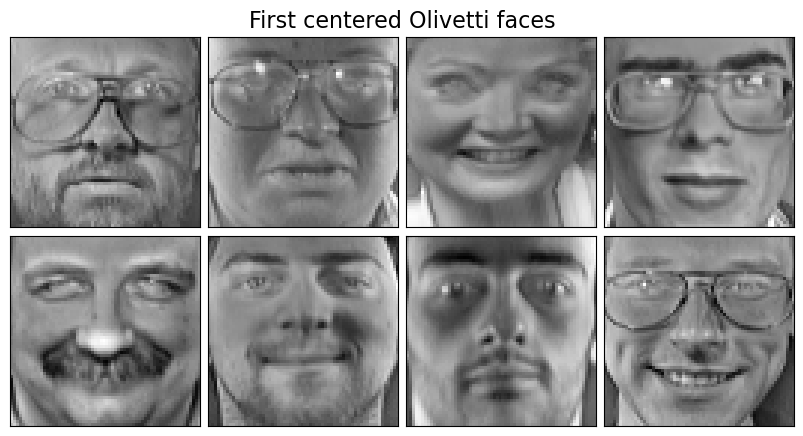

In [5]:
# #############################################################################
# Plot a sample of the input data

plot_gallery("First centered Olivetti faces", faces_centered[:n_components])

## 1. Comprimir las imágenes aplicando PCA

> _Comprimir las imágenes aplicando PCA de manera que se preserve el 95 % de la varianza y mostrar las 8 primeras imágenes originales y descomprimidas. Crear un nuevo dataset con las imágenes comprimidas. ¿Qué número de píxeles quedan al comprimir?_

Proporción de varianza explicada por cada componente principal:
[0.18154673 0.10176538 0.07104161 0.05596607 0.04068938 0.03342145
 0.02613545 0.02586311 0.0215212  0.02033981 0.01828899 0.01626768
 0.01529053 0.01358848 0.01275672 0.01195729 0.0107786  0.00958763
 0.0095376  0.0090426  0.00799512 0.00761197 0.00733871 0.00697001
 0.00676431 0.00659073 0.006307   0.00588069 0.00563022 0.00514244
 0.00498559 0.00466561 0.0043135  0.00415043 0.00402153 0.0039979
 0.00380723 0.0035888  0.00351131 0.00331546 0.00326027 0.00317734
 0.00310838 0.00300001 0.00293483 0.00285184 0.00282687 0.00271932
 0.00260842 0.00252944 0.0024539  0.00242579 0.0023127  0.00227085
 0.00221528 0.00218207 0.00210929 0.00206075 0.0020159  0.0020074
 0.00194547 0.001928   0.00187863 0.001835   0.00179168 0.00174627
 0.00172669 0.00169853 0.00164728 0.0016267  0.00160915 0.00157466
 0.00154375 0.00150075 0.00148341 0.00145675 0.00141629 0.00140056
 0.00139173 0.00135894 0.00133433 0.00130725 0.00126171 0.00124014


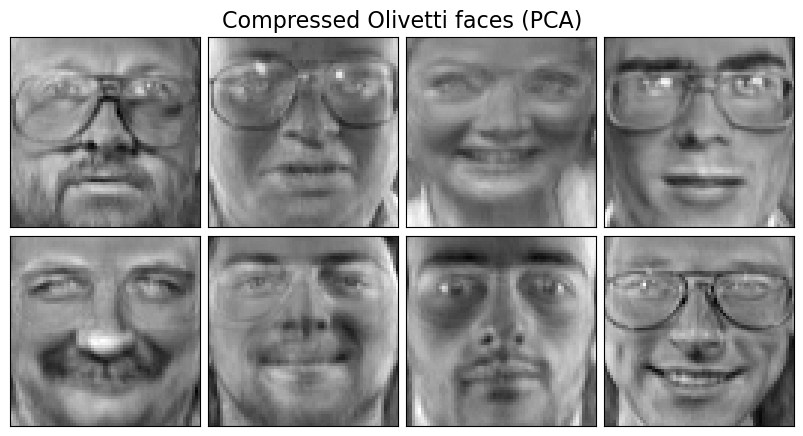

In [6]:
X = faces_centered

# PCA manteniendo el 95% de la varianza explicada en los datos
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)

# Imprimir resultados
print("Proporción de varianza explicada por cada componente principal:")
print(pca.explained_variance_ratio_)
print(f"\nNúmero de componentes principales seleccionados para explicar el 95% de la varianza: {pca.n_components_}")

# Recuperar el conjunto de datos reducido (comprimido) a la forma original aproximada
X_recovered = pca.inverse_transform(X_pca)
# Visualizar las imágenes comprimidas recuperadas
plot_gallery("Compressed Olivetti faces (PCA)", X_recovered[:n_components])

#### Análisis del resultado

El resultado muestra que se han seleccionado **144 componentes principales** para explicar el 95% de la varianza en los datos originales, lo que sugiere que los datos de las imágenes tienen una alta dimensionalidad. La combinación de estos 144 atributos explican la mayor parte de la variabilidad de los datos. 

Las **imágenes reconstruidas** a partir del conjunto reducido conservan la estructura general y las características principales, aunque presentan una ligera pérdida de detalles finos debido a la compresión. Esto demuestra que el PCA logra una reducción de la dimensionalidad, pero con la capacidad de poder revertir la compresión y poder reconstruir las imágenes.

El enunciado pregunta por el **número de píxeles** que quedan al comprimir. Podemos considerar que son 144 (correspondientes a los componentes principales). Sin embargo, no podemos decir qeu estos 144 píxeles comprimidos son un arreglo de 12x12, porque PCA no mantiene una estructura espacial en la reducción de dimensionalidad. Simplemente son componentes lineales que combinan la información de los píxeles originales de manera abstracta, sin preservar las posiciones espaciales de los píxeles en la imagen.

## 2. Comprimir las imágenes usando LDA

> _Se deberá hacer lo mismo que en la sección 1, pero usando LDA._

In [7]:
# Obtener la variable objetivo y
y = faces.target

# Ajustar LDA para maximizar la separabilidad entre clases
lda = LDA(n_components=None)  # Si None, n_components <= min(n_classes - 1, n_features)
X_lda = lda.fit_transform(faces_centered, y)

# Imprimir información sobre la reducción
print(f"Número de componentes seleccionados (dimensión reducida): {lda.explained_variance_ratio_.shape[0]}")
print("\nProporción de varianza explicada por cada componente discriminante:")
print(lda.explained_variance_ratio_)
print("\nSuma acumulativa de la varianza explicada:")
cumulative_variance = np.cumsum(lda.explained_variance_ratio_)
print(cumulative_variance)

# Encontrar el número mínimo de componentes que preservan al menos el 95% de la varianza
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nNúmero de componentes que preservan al menos el 95% de la varianza: {n_components_95}")

Número de componentes seleccionados (dimensión reducida): 39

Proporción de varianza explicada por cada componente discriminante:
[0.14205503 0.09097394 0.08424855 0.07333779 0.05890798 0.04934372
 0.04829711 0.04139012 0.04007303 0.03325923 0.03248128 0.0254353
 0.02404054 0.01983478 0.0187137  0.01764835 0.01734957 0.01644644
 0.01487947 0.01410414 0.01322641 0.01225737 0.01123731 0.01033146
 0.00980418 0.00903552 0.00847914 0.00794036 0.00724262 0.00710576
 0.0066791  0.0060834  0.00551424 0.00496154 0.00416178 0.00391623
 0.0032205  0.00316567 0.00281732]

Suma acumulativa de la varianza explicada:
[0.14205503 0.23302898 0.31727752 0.3906153  0.4495233  0.498867
 0.5471641  0.5885542  0.62862724 0.66188645 0.6943677  0.719803
 0.7438435  0.76367825 0.78239197 0.8000403  0.81738985 0.83383626
 0.8487157  0.86281985 0.87604624 0.88830364 0.89954096 0.9098724
 0.9196766  0.9287121  0.93719125 0.9451316  0.9523742  0.95948
 0.9661591  0.97224253 0.9777568  0.98271835 0.9868801  0.99079

#### Análisis del resultado
Nótese que LDA es un método supervisado, ya que para realizar el `fit_transform()`, necesitamos pasarle tanto los valoes de las características como la clase a la que pertenecen. 

Tras realizar el análisis anterior, he valorado estas dos opciones:

1. Elegir **39 componentes**: en LDA, si establecemos `n_components=None`, selecciona automáticamente hasta `min(n_classes - 1, n_features)` componentes con el objetivo de maximizar la separabilidad entre clases. En este caso, la suma de las varianzas explicadas es igual a 1.0. 
2. Elegir **29 componentes**: Esta opción permite una solución más compacta, manteniendo solo la información necesaria para alcanzar un umbral del 95% de varianza explicada, lo que resulta en una reducción de la dimensionalidad sin perder demasiado en términos de varianza.

El enunciado sugiere preservar el 95% de la varianza en PCA. El 95% de la varianza se refiere a una práctica común en PCA para elegir cuántos componentes principales conservar, asegurando que se mantenga la mayor parte de la información (varianza) de los datos originales con una cantidad reducida de dimensiones. Esto es válido teniendo en cuenta que PCA únicamente se basa en la varianza total de los datos, y no cuenta con la información de las clases, ya que es un método no supervisado. En cuanto a LDA, el enunciado no menciona explícitamente este criterio de varianza, lo que me ha generado dudas y por lo que he realizado el análisis anterior. En el caso de LDA, LDA refleja la "varianza explicada" en términos de la capacidad de los componentes para discriminar entre clases de manera supervisada, y no se enfoca en la varianza total como PCA. Dicho de otro modo, LDA se enfoca en la capacidad de los componentes para distinguir las clases. Por tanto, no he encontrado una relación clara en aplicar el mismo criterio del 95% de varianza en el caso de LDA, y he optado por utilizar los **39 componentes** para evaluar de manera más precisa el rendimiento real de LDA.

Por otra parte, para responder la pregunta del enunciado **_¿Qué número de píxeles quedan al comprimir?_**, en este caso  también podemos decir que el número de _"píxeles"_ que quedan tras aplicar LDA es 39. Sin embargo, es importante recordar que estas 39 características no corresponden a una estructura de imagen 2D, como lo harían los píxeles en una imagen, sino que son las nuevas dimensiones que mejor separan las clases en el espacio proyectado. Por tanto, es mejor llamarles componentes principales. La palabra _píxeles_ podría inducir a error.


En cuanto a **mostrar las 8 primeras imágenes originales y descomprimidas**, en LDA no podemos utilizar el método `inverse_transform`. Esto se debe a que la LDA no está diseñada para ser invertida como lo están otros modelos de reducción de dimensionalidad, como PCA. El objetivo de LDA es **maximizar la separabilidad entre clases**. Por lo tanto,realizar la transformación inversa no es una práctica estándar ni está respaldada por la documentación oficial de `scikit-learn`.

Tras varias búsquedas en internet, he encontrado la forma en la que podríamos intentar aproximar los datos comprimidos manualmente utilizando las componentes discriminantes `lda.scalings_` y la media de los datos originales, de la forma en que se puede ver en el código de abajo. Sin embargo, debido a que **LDA no preserva necesariamente la información necesaria para una reconstrucción precisa**, hay que tener en cuenta que este es el motivo de que **los datos reconstruidos pueden diferir significativamente de los originales**.

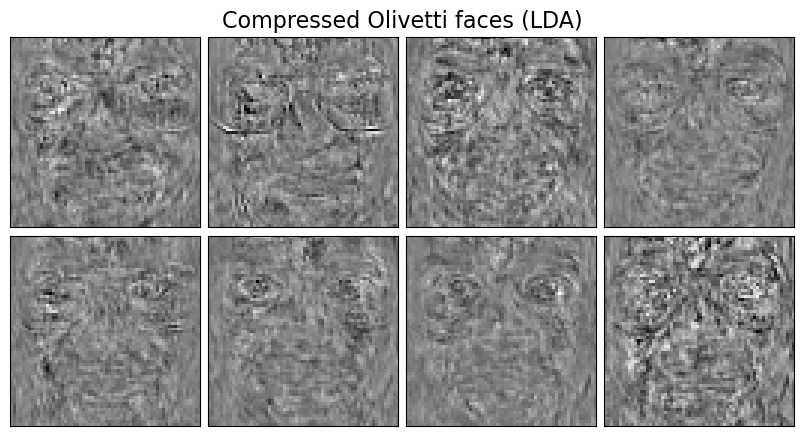

In [8]:
# Visualizar imágenes comprimidas
# Reconstrucción manual de los datos
X_recovered_lda = np.dot(X_lda, lda.scalings_.T) + faces_centered.mean(axis=0)

# Parámetros para la visualización
plot_gallery("Compressed Olivetti faces (LDA)", X_recovered_lda[:n_components])

## 3. Dividir los datos en conjunto de entrenamiento y test

> _Dividir los datos en conjunto de entrenamiento y test de manera que el conjunto de test sea un 20 % del total, tanto para los datos originales como para los comprimidos con PCA y LDA. Repasar la documentación de scikit learn referida a SVM para ver si es conveniente aplicar transformaciones a los datos._

He dividido los datos en un conjunto de entrenamiento (80%) y uno de prueba (20%) utilizando la función `train_test_split` de `scikit-learn`, asegurándome de que ambas particiones mantuvieran la misma distribución de clases a través del parámetro `stratify=y`. 

Posteriormente, he escalado los datos con `StandardScaler` para normalizar las características, lo que es necesario en los modelos de clasificación como el SVC. La normalización asegura que todas las características tengan una media de 0 y una desviación estándar de 1, lo cual evita que las diferencias en las magnitudes de las características afecten el rendimiento del modelo, mejorando su convergencia y precisión al hacer que todas las características tengan igual importancia en el proceso de clasificación.

### Datos Originales

In [9]:
# Dividir los datos en entrenamiento (80%) y prueba (20%)
X_orig_train, X_orig_test, y_orig_train, y_orig_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalar los datos
scaler = StandardScaler()
X_orig_train_scaled = scaler.fit_transform(X_orig_train)
X_orig_test_scaled = scaler.transform(X_orig_test)

### Datos PCA

In [10]:
# Dividir los datos en entrenamiento (80%) y prueba (20%)
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)

# Escalar los datos
scaler = StandardScaler()
X_pca_train_scaled = scaler.fit_transform(X_pca_train)
X_pca_test_scaled = scaler.transform(X_pca_test)

### Datos LDA

In [11]:
# Dividir los datos en entrenamiento (80%) y prueba (20%)
X_lda_train, X_lda_test, y_lda_train, y_lda_test = train_test_split(X_lda, y, test_size=0.2, random_state=42, stratify=y)

# Escalar los datos
scaler = StandardScaler()
X_lda_train_scaled = scaler.fit_transform(X_lda_train)
X_lda_test_scaled = scaler.transform(X_lda_test)

## 4. Afinación de hiperparámetros para LinearSVC y SVC 

> _Realizar una afinación de hiperparámetros para LinearSVC y SVC con kernel ’rbf’ para la clasificación de los datos originales, realizando la búsqueda de parámetros como se comentó en las subsecciones 7.4.1 y 7.4.2 (cambiando SVR por SVC). Usar para el parámetro ’cv’ de GridSearchCV el valor 10. Medir los tiempos en milisegundos de las dos ejecuciones de GridSearchCV. Se recomienda usar multiproceso._

En las secciones 4, 5 y 6 he realizado la afinación de hiperparámetros con el objetivo optimizar los parámetros de **C** y **γ** mediante el uso de **GridSearchCV**. Para este proceso, siguiendo las indicaciones de la guía de la asignatura y basándome en lo aprendido durante la práctica anterior, he hecho dos búsquedas de parámetros utilizando una escala logarítmica, con los rangos de valores para **C** y **γ** definidos mediante `np.logspace`. Además, he refinado cada cada búsqueda en los valores obtenidos en la búsqueda anterior. Finalmente, en algún caso he realizado también una tercera búsqueda utilizando una escala lineal para afinar aún más los parámetros.

En cuanto al **cross validation**, he utilizado `cv=5` porque al intentar realizar la búsqueda con `cv=10` encontré un error: `ValueError: n_splits=10 cannot be greater than the number of members in each class.` Este problema se debe a que Scikit-learn por defecto para clasificadores multiclase utiliza la **validación cruzada estratificada** (`StratifiedKFold`). En este conjunto de datos, las clases (caras en el conjunto de datos de Olivetti) tienen menos de 10 muestras y no pueden ser divididas en 10 partes. Siguiendo las recomendaciones del foro de la asignatura, decidí reducir el número de pliegues a 5 para solucionar este inconveniente.

En cuanto al **multiprocesado**, he utilizado el parámetro `n_jobs` en `GridSearchCV` para paralelizar los cálculos y acelerar el ajuste de los modelos.

In [12]:
def evaluar_modelo(model, X_data, y_data, dataset_type, model_type):
    """
    Visualiza la matriz de confusión para un conjunto de datos dado, calcula el accuracy y muestra el classification report.
    
    Parameters:
    - model: El modelo entrenado.
    - X_data: Características.
    - y_data: Etiquetas.
    - dataset_type: El tipo de conjunto de datos (Entrenamiento o Prueba).
    """
    # Hacer predicciones
    y_pred = model.predict(X_data)

    # Calcular el accuracy y el classification report
    accuracy = accuracy_score(y_data, y_pred)
    print(f"Accuracy ({dataset_type}):", accuracy)
    print(f"Classification report ({dataset_type}):")
    print(classification_report(y_data, y_pred, zero_division=0))

    # Calcular la matriz de confusión
    conf_matrix = confusion_matrix(y_data, y_pred)
    
    # Visualizar la matriz de confusión
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
                xticklabels=model.classes_, yticklabels=model.classes_,
                cbar_kws={'label': 'Frecuencia'})
    plt.xlabel('Clases Predichas')
    plt.ylabel('Clases Reales')
    plt.title(f'Matriz de Confusión - {model_type} ({dataset_type})')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

### LinearSVC

#### Primera búsqueda

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Tiempo de ejecución del GridSearchCV: 133508.16 ms

Mejores parámetros encontrados: {'C': 0.001}

+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++
Accuracy (Entrenamiento): 1.0
Classification report (Entrenamiento):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00         8
           6       1.00      1.00      1.00         8
           7       1.00      1.00      1.00         8
           8       1.00      1.00      1.00         8
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         8
          11       1.00      1.00      1.00         8
          12    

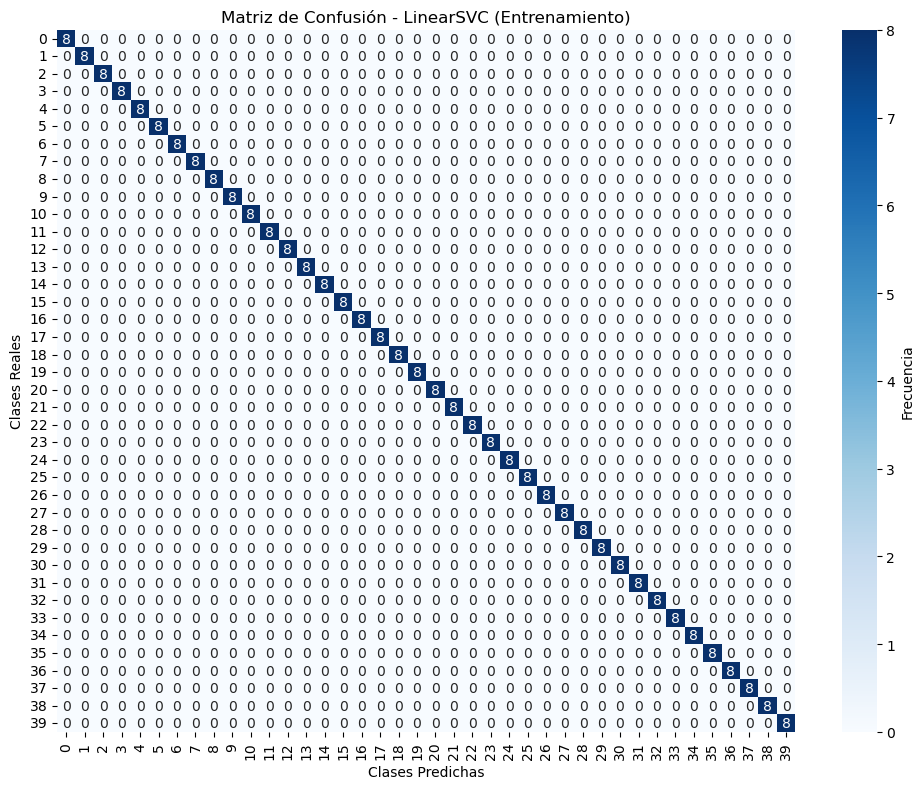


+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++
Accuracy (Prueba): 0.925
Classification report (Prueba):
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       1.00      1.00      1.00         2
           2       0.67      1.00      0.80         2
           3       0.00      0.00      0.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       0.67      1.00      0.80         2
          14       0.40      1.00      0.57         2
          15       1.00      1.

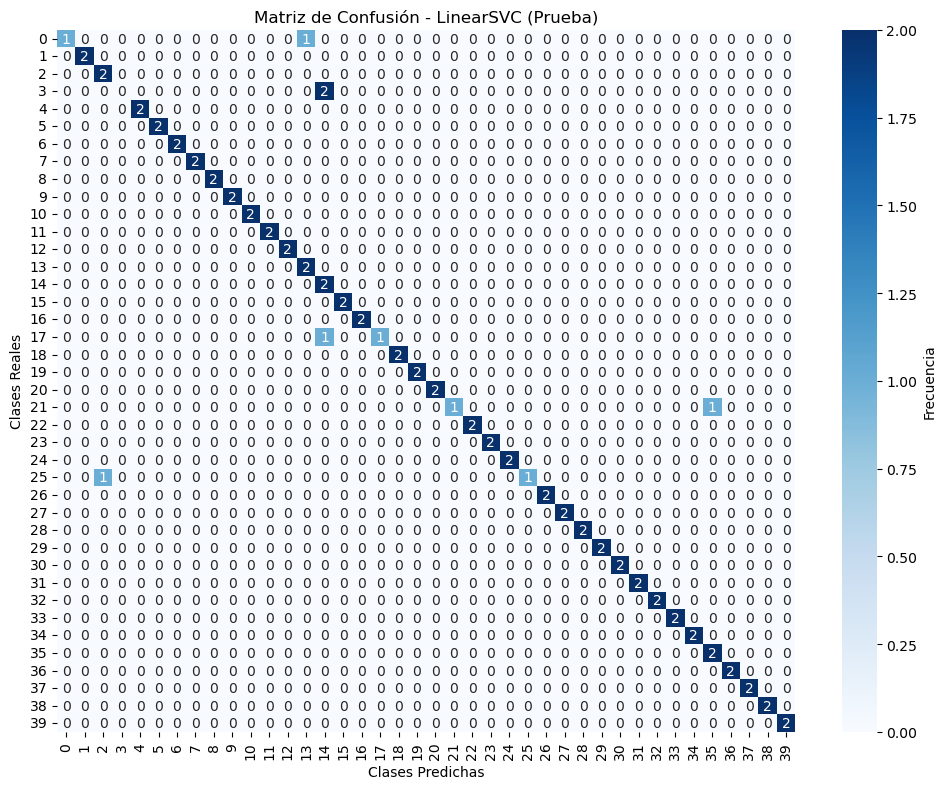

In [13]:
# Parámetros de búsqueda para LinearSVC
param_grid = {
    'C': np.logspace(-3, 2, 6),  # Valores logarítmicos desde 10^-3 hasta 10^2
}

# Iniciar la medición del tiempo
start_time = time.time()

# Crear el objeto GridSearchCV y ajustar a los datos
grid = GridSearchCV(LinearSVC(random_state=42), param_grid, refit=True, verbose=2, cv=5, n_jobs=-1)
grid.fit(X_orig_train_scaled, y_orig_train)

# Medir el tiempo después de GridSearchCV
end_time = time.time()
elapsed_time_ms = (end_time - start_time) * 1000  # en milisegundos
print(f"\nTiempo de ejecución del GridSearchCV: {elapsed_time_ms:.2f} ms")

# Mejor estimador
print("\nMejores parámetros encontrados:", grid.best_params_)
best_model = grid.best_estimator_

# Evaluación de los resultados
print("\n+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++")
evaluar_modelo(best_model, X_orig_train_scaled, y_orig_train, dataset_type="Entrenamiento", model_type="LinearSVC")
print("\n+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++")
evaluar_modelo(best_model, X_orig_test_scaled, y_orig_test, dataset_type="Prueba", model_type="LinearSVC")

#### Segunda búsqueda

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Tiempo de ejecución del GridSearchCV: 32580.67 ms

Mejores parámetros encontrados: {'C': 0.001}

+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++
Accuracy (Entrenamiento): 1.0
Classification report (Entrenamiento):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00         8
           6       1.00      1.00      1.00         8
           7       1.00      1.00      1.00         8
           8       1.00      1.00      1.00         8
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         8
          11       1.00      1.00      1.00         8
          12     

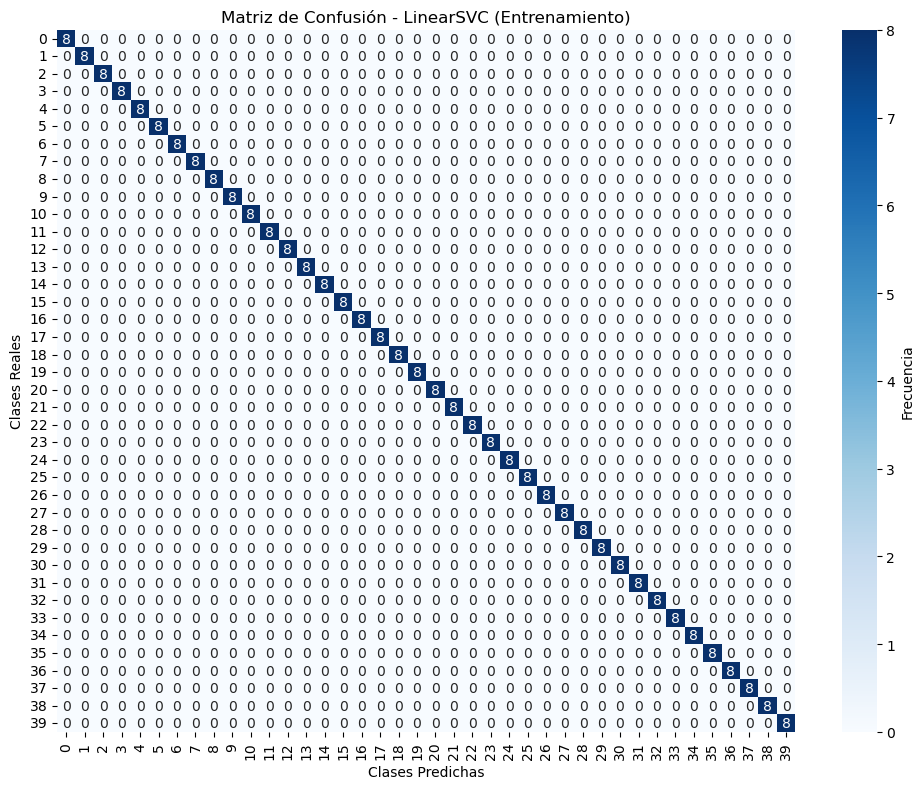


+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++
Accuracy (Prueba): 0.925
Classification report (Prueba):
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       1.00      1.00      1.00         2
           2       0.67      1.00      0.80         2
           3       0.00      0.00      0.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       0.67      1.00      0.80         2
          14       0.40      1.00      0.57         2
          15       1.00      1.

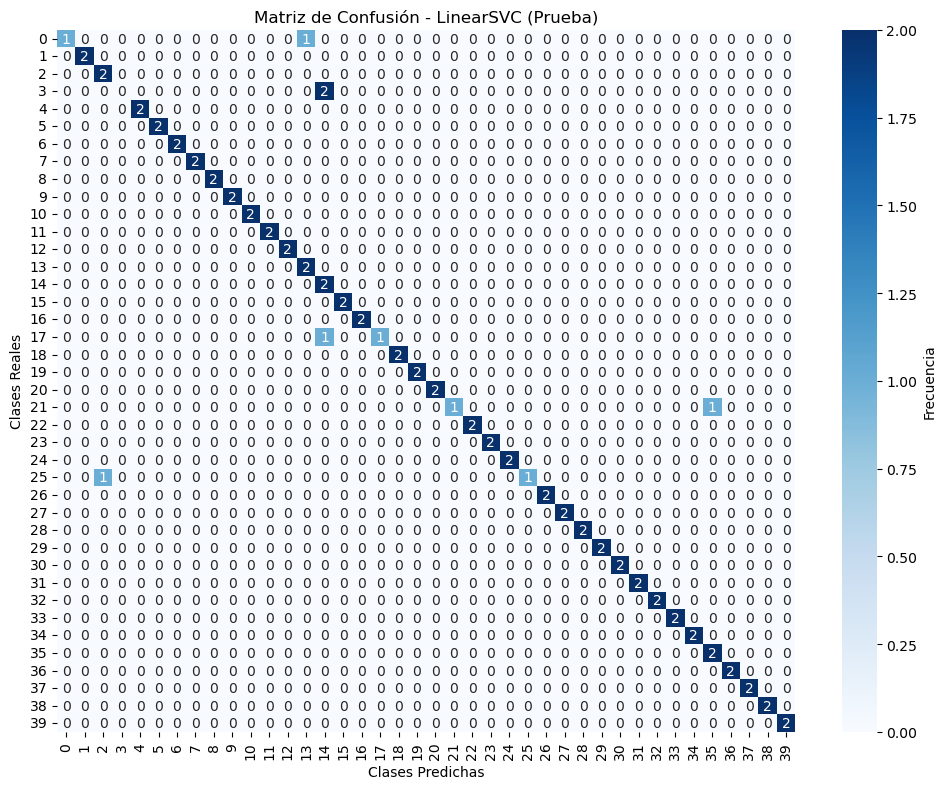

In [14]:
# Parámetros de búsqueda para LinearSVC
param_grid = {
    'C': np.logspace(-5, -2, 4),
}

# Iniciar la medición del tiempo
start_time = time.time()

# Crear el objeto GridSearchCV y ajustar a los datos
grid = GridSearchCV(LinearSVC(random_state=42), param_grid, refit=True, verbose=2, cv=5, n_jobs=-1)
grid.fit(X_orig_train_scaled, y_orig_train)

# Medir el tiempo después de GridSearchCV
end_time = time.time()
elapsed_time_ms = (end_time - start_time) * 1000  # en milisegundos
print(f"\nTiempo de ejecución del GridSearchCV: {elapsed_time_ms:.2f} ms")

# Mejor estimador
print("\nMejores parámetros encontrados:", grid.best_params_)
best_model = grid.best_estimator_

# Evaluación de los resultados
print("\n+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++")
evaluar_modelo(best_model, X_orig_train_scaled, y_orig_train, dataset_type="Entrenamiento", model_type="LinearSVC")
print("\n+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++")
evaluar_modelo(best_model, X_orig_test_scaled, y_orig_test, dataset_type="Prueba", model_type="LinearSVC")

### SVC


#### Primera búsqueda

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Tiempo de ejecución del GridSearchCV: 2097.94 ms

Mejores parámetros encontrados: {'C': 0.01, 'gamma': 0.1}

+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++
Accuracy (Entrenamiento): 1.0
Classification report (Entrenamiento):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00         8
           6       1.00      1.00      1.00         8
           7       1.00      1.00      1.00         8
           8       1.00      1.00      1.00         8
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         8
          11       1.00      1.00      1.00         8
   

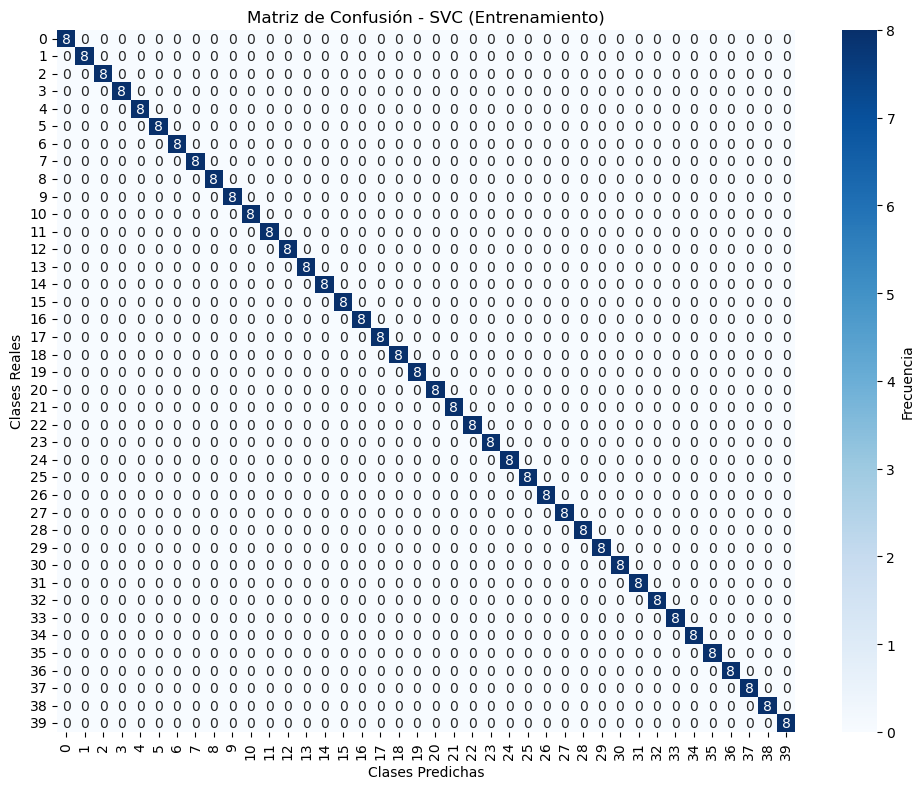


+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++
Accuracy (Prueba): 0.8125
Classification report (Prueba):
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       0.00      0.00      0.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       0.67      1.00      0.80         2
           8       1.00      0.50      0.67         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       0.50      1.00      0.67         2
          15       1.00      1

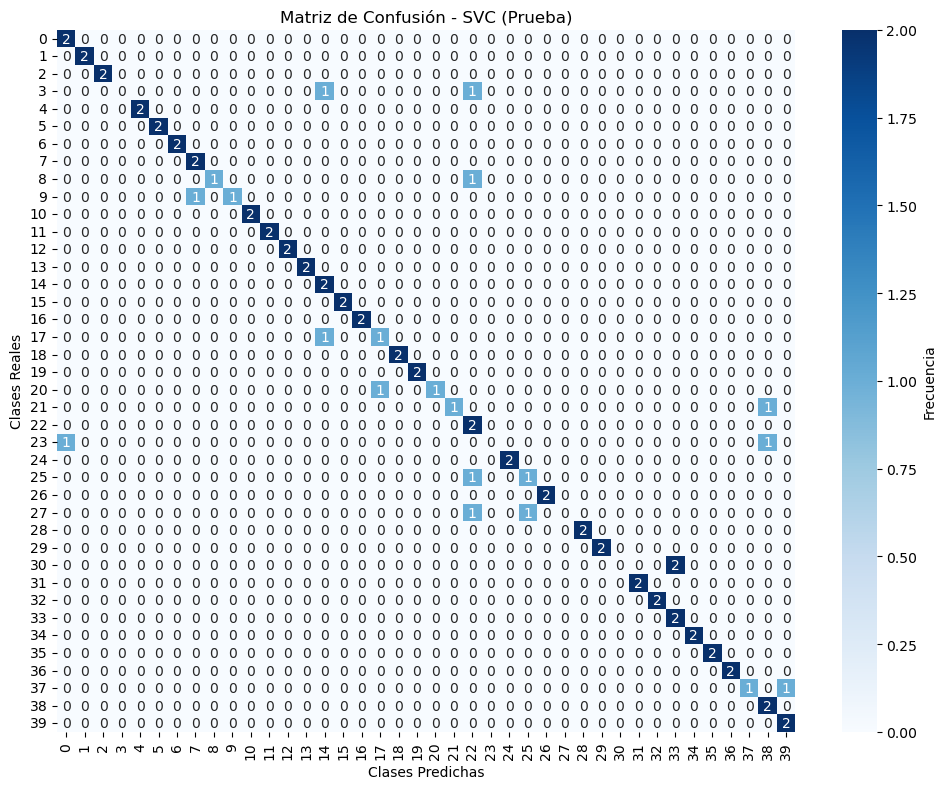

In [15]:
# Parámetros de búsqueda para el GridSearchCV
param_grid = {
    'C': np.logspace(-2, 2, 5),  # Rango de 10^-2 a 10^2 (5 valores logarítmicos)
    'gamma': np.logspace(-2, 2, 5)
}

# Iniciar la medición del tiempo
start_time = time.time()

# Crear el objeto GridSearchCV y ajustar a los datos
grid = GridSearchCV(SVC(random_state=42, kernel='rbf'), param_grid, refit=True, verbose=2, cv=5, n_jobs=-1)
grid.fit(X_orig_train_scaled, y_orig_train)

# Medir el tiempo después de GridSearchCV
end_time = time.time()
elapsed_time_ms = (end_time - start_time) * 1000  # en milisegundos
print(f"\nTiempo de ejecución del GridSearchCV: {elapsed_time_ms:.2f} ms")

# Mejor estimador
print("\nMejores parámetros encontrados:", grid.best_params_)
best_model = grid.best_estimator_

# Evaluación de los resultados
print("\n+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++")
evaluar_modelo(best_model, X_orig_train_scaled, y_orig_train, dataset_type="Entrenamiento", model_type="SVC")
print("\n+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++")
evaluar_modelo(best_model, X_orig_test_scaled, y_orig_test, dataset_type="Prueba", model_type="SVC")

#### Segunda búsqueda

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Tiempo de ejecución del GridSearchCV: 3551.08 ms

Mejores parámetros encontrados: {'C': 1e-05, 'gamma': 0.1}

+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++
Accuracy (Entrenamiento): 1.0
Classification report (Entrenamiento):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00         8
           6       1.00      1.00      1.00         8
           7       1.00      1.00      1.00         8
           8       1.00      1.00      1.00         8
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         8
          11       1.00      1.00      1.00         8
  

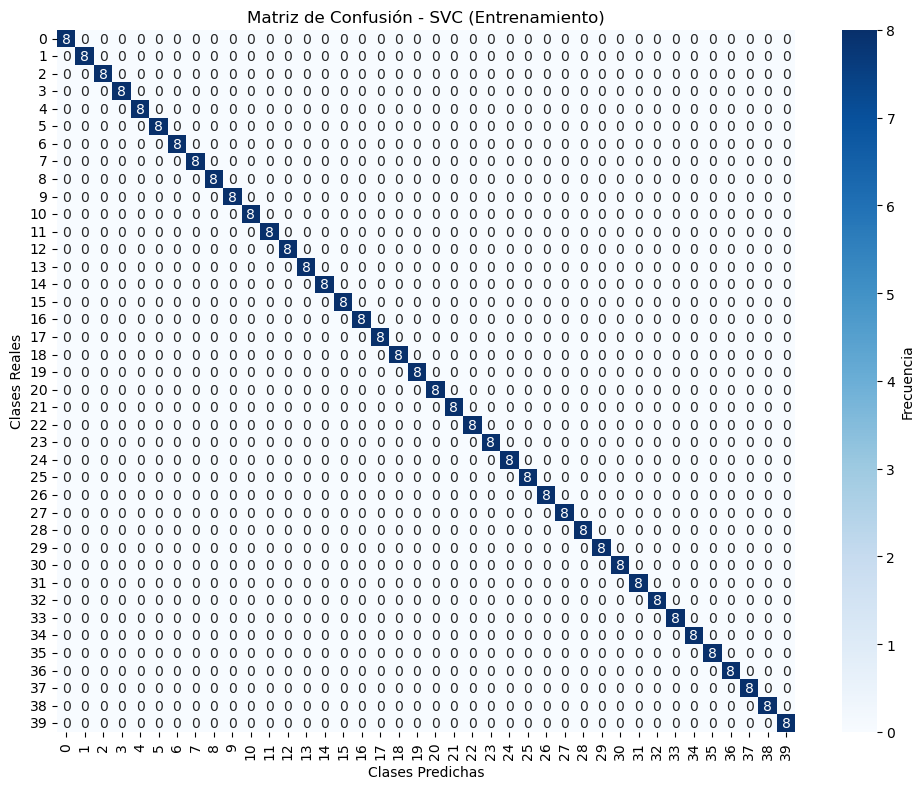


+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++
Accuracy (Prueba): 0.8625
Classification report (Prueba):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       0.00      0.00      0.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       0.67      1.00      0.80         2
           8       1.00      0.50      0.67         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       0.50      1.00      0.67         2
          15       1.00      1

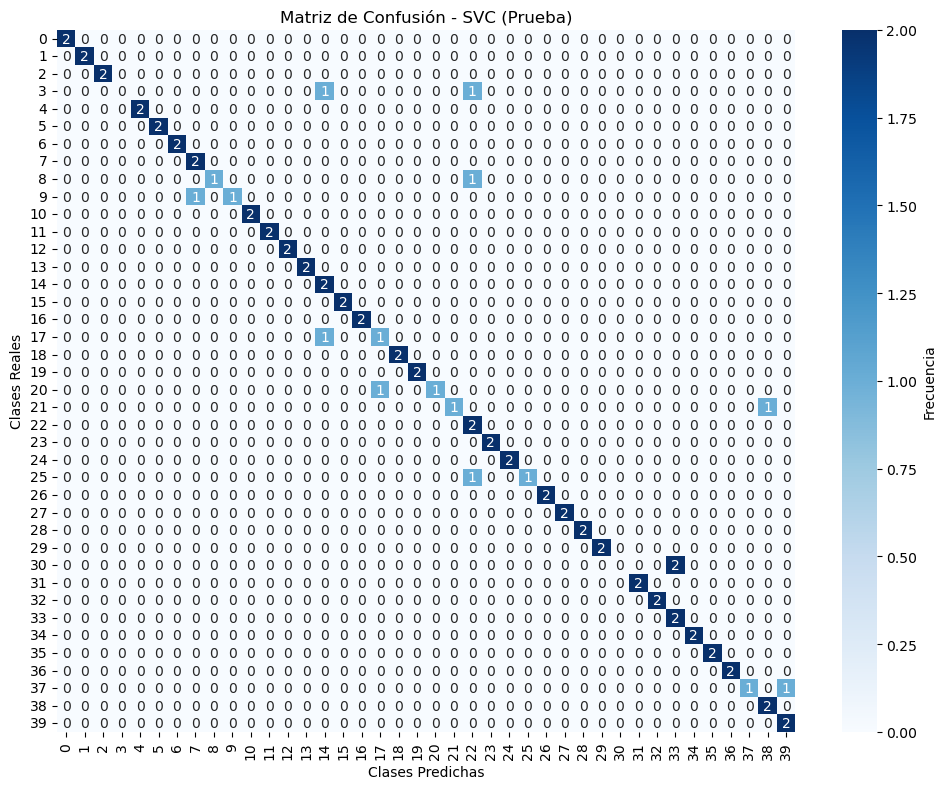

In [16]:
# Parámetros de búsqueda para el GridSearchCV
param_grid = {
    'C': np.logspace(-5, -1, 5), # 0.00001, 0.0001 , 0.001  , 0.01   , 0.1
    'gamma': np.logspace(-4, 0, 5) # 0.0001, 0.001 , 0.01  , 0.1   , 1.
}

# Iniciar la medición del tiempo
start_time = time.time()

# Crear el objeto GridSearchCV y ajustar a los datos
grid = GridSearchCV(SVC(random_state=42, kernel='rbf'), param_grid, refit=True, verbose=2, cv=5, n_jobs=-1)
grid.fit(X_orig_train_scaled, y_orig_train)

# Medir el tiempo después de GridSearchCV
end_time = time.time()
elapsed_time_ms = (end_time - start_time) * 1000  # en milisegundos
print(f"\nTiempo de ejecución del GridSearchCV: {elapsed_time_ms:.2f} ms")

# Mejor estimador
print("\nMejores parámetros encontrados:", grid.best_params_)
best_model = grid.best_estimator_

# Evaluación de los resultados
print("\n+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++")
evaluar_modelo(best_model, X_orig_train_scaled, y_orig_train, dataset_type="Entrenamiento", model_type="SVC")
print("\n+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++")
evaluar_modelo(best_model, X_orig_test_scaled, y_orig_test, dataset_type="Prueba", model_type="SVC")

### Conclusiones 

#### Conclusiones hiperparámetros LinearSVC

En este proceso de afinación de hiperparámetros para el modelo **LinearSVC**, se han realizado dos búsquedas progresivas para optimizar el valor de \(C\), utilizando GridSearchCV con una escala logarítmica. A continuación, se resumen los resultados obtenidos:

| **Búsqueda** | **Parámetros de C**                     | **Mejores parámetros encontrados** | **Accuracy Train** | **Accuracy Test** | **Tiempo de Ejecución (ms)** |
|--------------|-----------------------------------------|------------------------------------|----------------------------|-------------------|-----------------------------|
| **Primera**  | 0.001, 0.01, 0.1, 1, 10, 100           | **C = 0.001**                     | 1.0                        | 0.925             | 133508.16                  |
| **Segunda**  | 0.00001, 0.0001, 0.001, 0.01          | **C = 0.001**                     | 1.0                        | 0.925             | 32580.67                   |

En ambas búsquedas, el mejor valor de \(C\) encontrado fue **\(C = 0.001\)**, logrando un accuracy del **100% en el conjunto de entrenamiento** y un **92.5% en el conjunto de prueba**.

Dado que no se ha obtenido mejora tras la segunda búsqueda y llega al mismo resultado, se considera que el parámetro \(C = 0.001\) es el más adecuado para este modelo. Por lo tanto, no es necesario realizar más búsquedas para optimizar este hiperparámetro.


#### Conclusiones hiperparámetros SVC

En este proceso de afinación de hiperparámetros para el modelo SVC con kernel RBF, se han realizado dos búsquedas de parámetros de manera progresiva para optimizar los valores de C y γ. Resumen de los resultados obtenidos:

| **Búsqueda** | **Parámetros de C**                 | **Parámetros de gamma**       | **Mejores parámetros encontrados**   | **Accuracy Train** | **Accuracy Test** | **Tiempo de Ejecución (ms)** |
|--------------|-------------------------------------|-------------------------------|--------------------------------------|--------------------|-------------------|-----------------------------|
| **Primera**  | 0.01, 0.1, 1, 10, 100               | 0.01, 0.1, 1, 10, 100         | **C = 0.01**, **gamma = 0.1**        | 1.0                | 0.8125             | 2097.94                   |
| **Segunda**  | 0.00001, 0.0001, 0.001, 0.01, 0.1   | 0.0001, 0.001, 0.01, 0.1, 1   | **C = 0.00001**, **gamma = 0.1**     | 1.0                | 0.8625             | 3551.08                   |

Aunque ambos modelos tienen un rendimiento excelente en el entrenamiento, el modelo de la segunda búsqueda muestra un mejor desempeño en el conjunto de test, sugiriendo una mejor generalización. La primera búsqueda ha dado un accuracy de entrenamiento de 1.0, sin embargo, viendo que el accuracy bajaba mucho en el conjunto de test, he decidido realizar un segundo grid search bajando los valores de C para mejorar la capacidad de generalización y reducir posibles problemas de sobreajuste. 


#### Tiempo de ejecución

[PENDIENTE ANALIZAR]

Esto resalta la importancia de acotar el rango de los hiperparámetros en iteraciones futuras para reducir el tiempo de cómputo. Las búsquedas de SVC, aunque más lentas que la segunda búsqueda de LinearSVC, tuvieron tiempos cortos también.

Es posible que los tiempos de ejecución reflejen cómo el rango y la cantidad de valores evaluados en el grid afectan directamente el coste computacional.


## 5.LinearSVC y SVC sobre datos transformados con PCA

> _Realizar 4. usando los datos comprimidos mediante PCA._

### LinearSVC

#### Primera búsqueda

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Tiempo de ejecución del GridSearchCV: 3014.04 ms

Mejores parámetros encontrados: {'C': 0.001}

+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++
Accuracy (Entrenamiento): 1.0
Classification report (Entrenamiento):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00         8
           6       1.00      1.00      1.00         8
           7       1.00      1.00      1.00         8
           8       1.00      1.00      1.00         8
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         8
          11       1.00      1.00      1.00         8
          12      

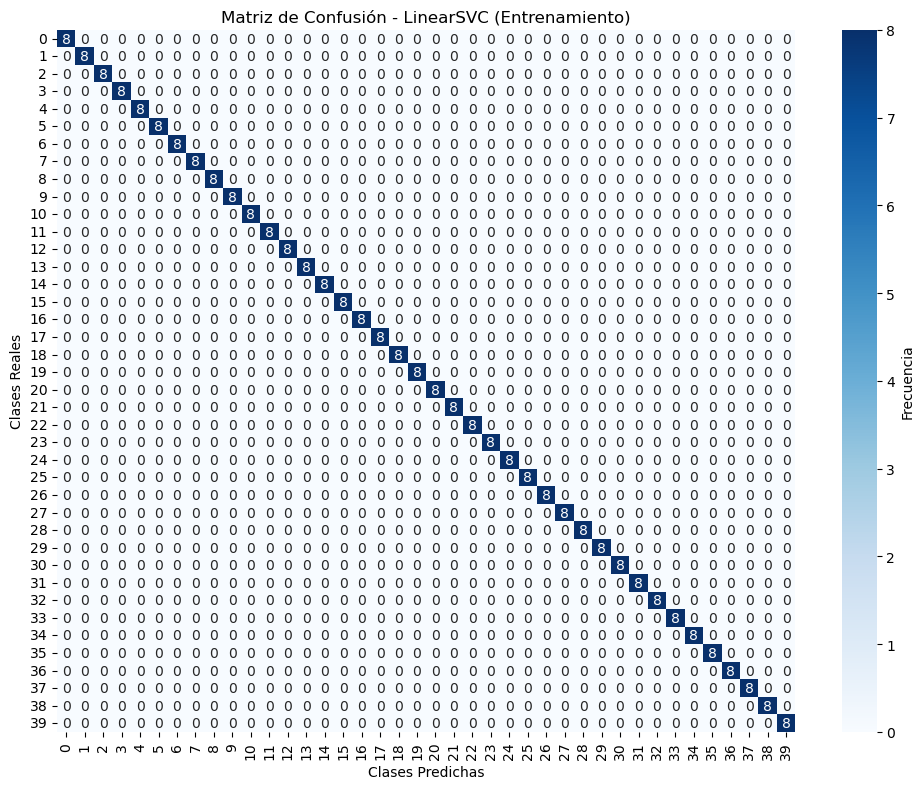


+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++
Accuracy (Prueba): 0.9375
Classification report (Prueba):
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       1.00      1.00      1.00         2
           2       0.67      1.00      0.80         2
           3       1.00      0.50      0.67         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      0.50      0.67         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       0.67      1.00      0.80         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      1

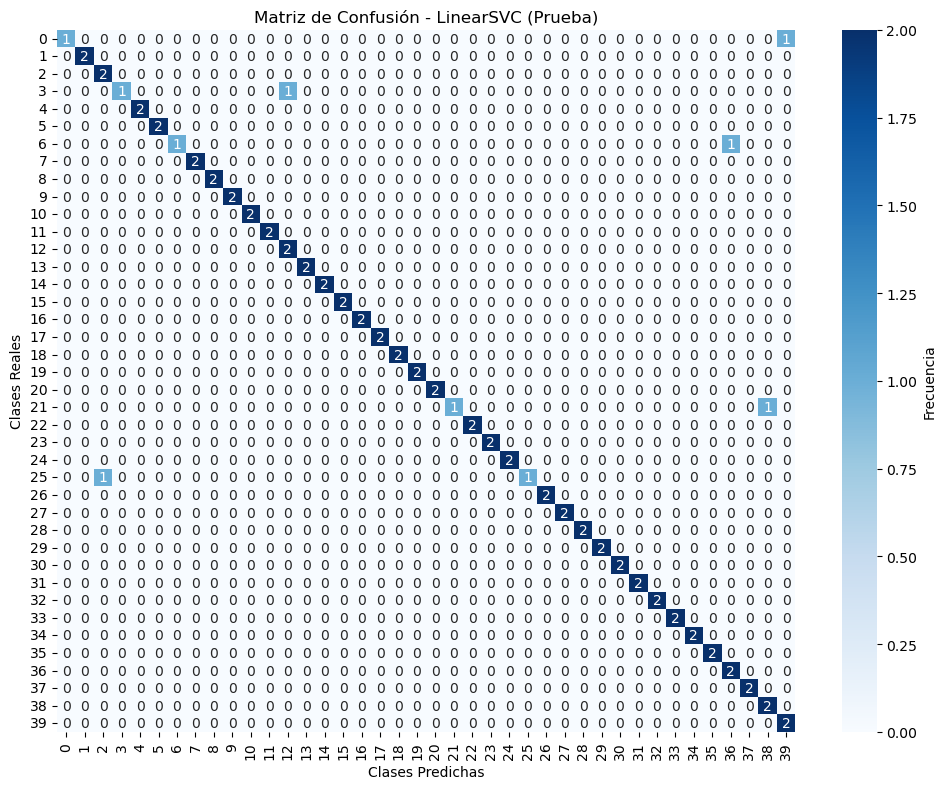

In [17]:
# Parámetros de búsqueda para LinearSVC
param_grid = {
    'C': np.logspace(-3, 2, 6),  # Valores logarítmicos desde 10^-3 hasta 10^2
}

# Iniciar la medición del tiempo
start_time = time.time()

# Crear el objeto GridSearchCV y ajustar a los datos
grid = GridSearchCV(LinearSVC(random_state=42), param_grid, refit=True, verbose=2, cv=5, n_jobs=-1)
grid.fit(X_pca_train_scaled, y_pca_train)

# Medir el tiempo después de GridSearchCV
end_time = time.time()
elapsed_time_ms = (end_time - start_time) * 1000  # en milisegundos
print(f"\nTiempo de ejecución del GridSearchCV: {elapsed_time_ms:.2f} ms")

# Mejor estimador
print("\nMejores parámetros encontrados:", grid.best_params_)
best_model = grid.best_estimator_

# Evaluación de los resultados
print("\n+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++")
evaluar_modelo(best_model, X_pca_train_scaled, y_pca_train, dataset_type="Entrenamiento", model_type="LinearSVC")
print("\n+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++")
evaluar_modelo(best_model, X_pca_test_scaled, y_pca_test, dataset_type="Prueba", model_type="LinearSVC")

#### Segunda búsqueda

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Tiempo de ejecución del GridSearchCV: 82.06 ms

Mejores parámetros encontrados: {'C': 0.001}

+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++
Accuracy (Entrenamiento): 1.0
Classification report (Entrenamiento):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00         8
           6       1.00      1.00      1.00         8
           7       1.00      1.00      1.00         8
           8       1.00      1.00      1.00         8
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         8
          11       1.00      1.00      1.00         8
          12       1

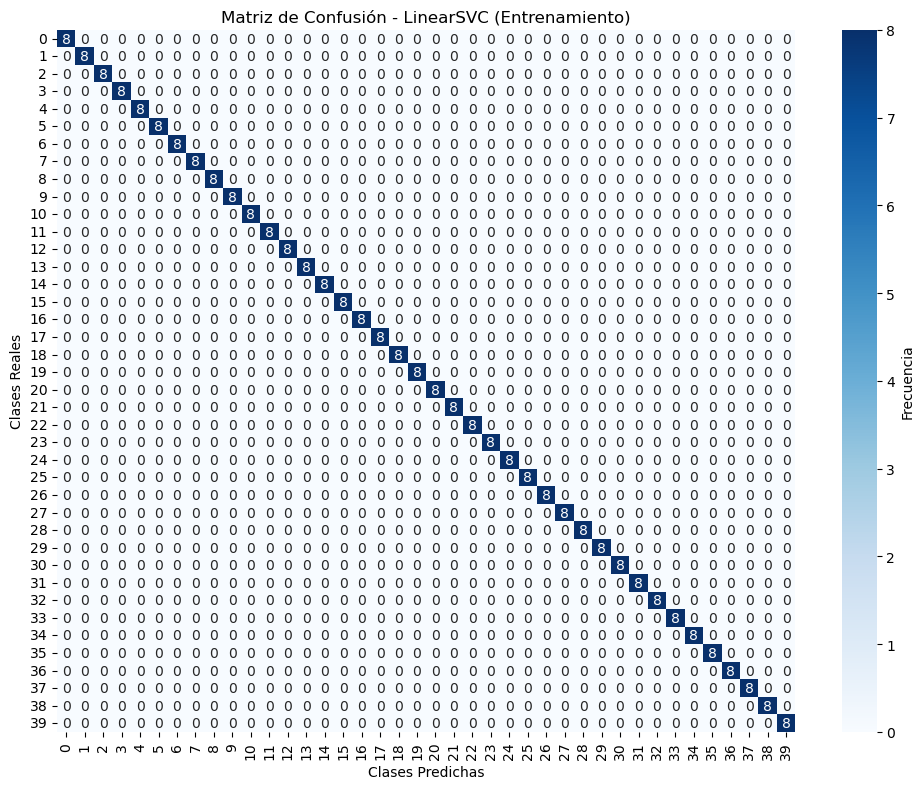


+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++
Accuracy (Prueba): 0.9375
Classification report (Prueba):
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       1.00      1.00      1.00         2
           2       0.67      1.00      0.80         2
           3       1.00      0.50      0.67         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      0.50      0.67         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       0.67      1.00      0.80         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      1

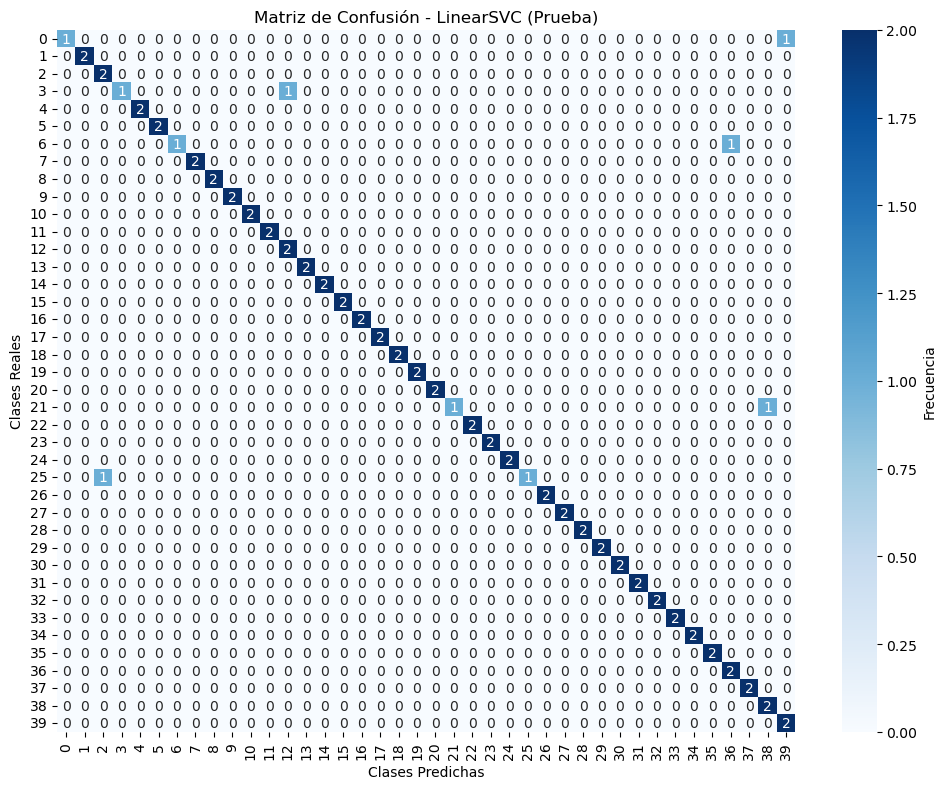

In [18]:
# Parámetros de búsqueda para LinearSVC
param_grid = {
    'C': np.logspace(-5, -2, 4), # 0.00001, 0.0001 , 0.001  , 0.01
}

# Iniciar la medición del tiempo
start_time = time.time()

# Crear el objeto GridSearchCV y ajustar a los datos
grid = GridSearchCV(LinearSVC(random_state=42), param_grid, refit=True, verbose=2, cv=5, n_jobs=-1)
grid.fit(X_pca_train_scaled, y_pca_train)

# Medir el tiempo después de GridSearchCV
end_time = time.time()
elapsed_time_ms = (end_time - start_time) * 1000  # en milisegundos
print(f"\nTiempo de ejecución del GridSearchCV: {elapsed_time_ms:.2f} ms")

# Mejor estimador
print("\nMejores parámetros encontrados:", grid.best_params_)
best_model = grid.best_estimator_

# Evaluación de los resultados
print("\n+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++")
evaluar_modelo(best_model, X_pca_train_scaled, y_pca_train, dataset_type="Entrenamiento", model_type="LinearSVC")
print("\n+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++")
evaluar_modelo(best_model, X_pca_test_scaled, y_pca_test, dataset_type="Prueba", model_type="LinearSVC")

### SVC

#### Primera búsqueda

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Tiempo de ejecución del GridSearchCV: 142.09 ms

Mejores parámetros encontrados: {'C': 10.0, 'gamma': 0.01}

+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++
Accuracy (Entrenamiento): 1.0
Classification report (Entrenamiento):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00         8
           6       1.00      1.00      1.00         8
           7       1.00      1.00      1.00         8
           8       1.00      1.00      1.00         8
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         8
          11       1.00      1.00      1.00         8
   

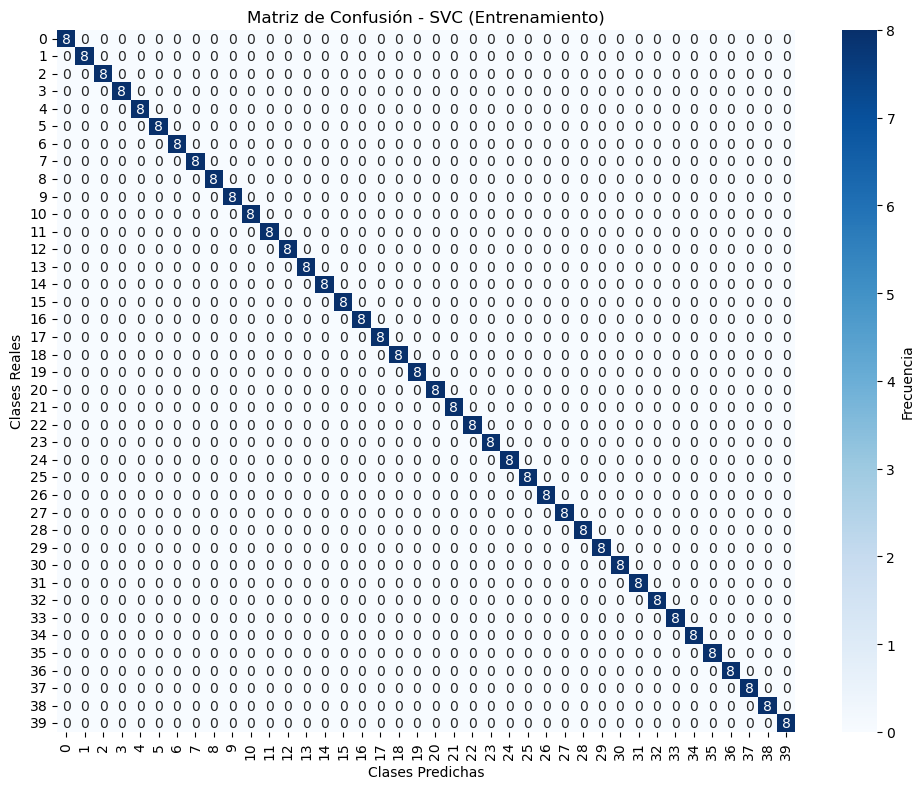


+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++
Accuracy (Prueba): 0.8
Classification report (Prueba):
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       1.00      0.50      0.67         2
           2       0.50      1.00      0.67         2
           3       1.00      0.50      0.67         2
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         2
           6       0.25      0.50      0.33         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       0.67      1.00      0.80         2
          12       0.67      1.00      0.80         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      1.00

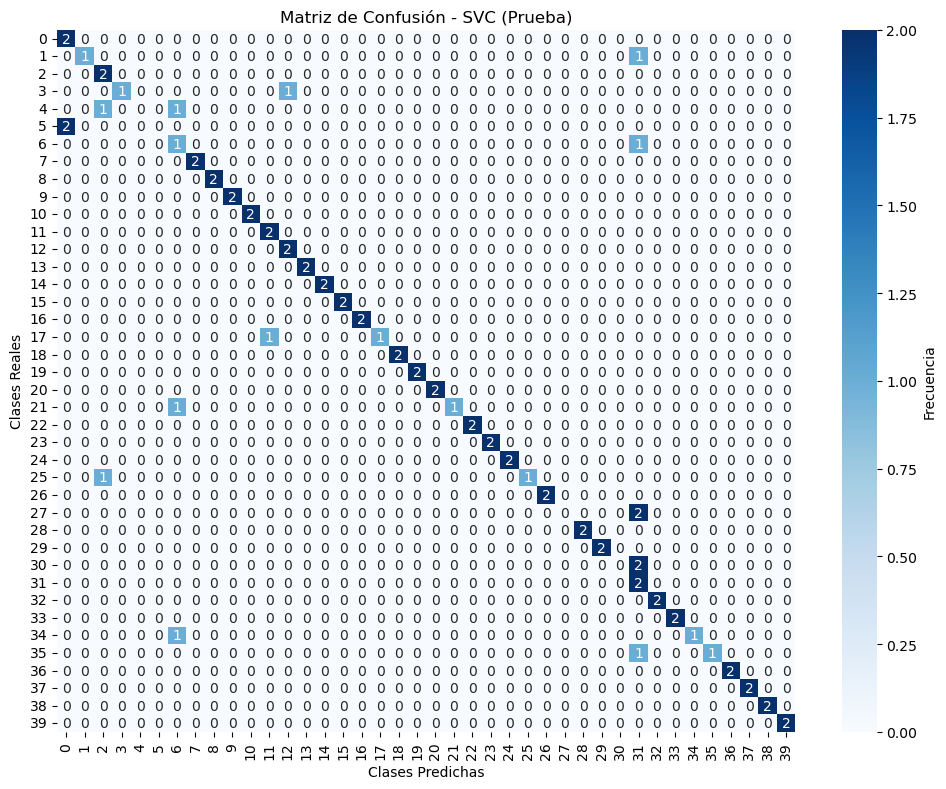

In [19]:
# Parámetros de búsqueda para el GridSearchCV
param_grid = {
    'C': np.logspace(-2, 2, 5),  # Rango de 10^-2 a 10^2 (5 valores logarítmicos)
    'gamma': np.logspace(-2, 2, 5)
}

# Iniciar la medición del tiempo
start_time = time.time()

# Crear el objeto GridSearchCV y ajustar a los datos
grid = GridSearchCV(SVC(random_state=42, kernel='rbf'), param_grid, refit=True, verbose=2, cv=5, n_jobs=-1)
grid.fit(X_pca_train_scaled, y_pca_train)

# Medir el tiempo después de GridSearchCV
end_time = time.time()
elapsed_time_ms = (end_time - start_time) * 1000  # en milisegundos
print(f"\nTiempo de ejecución del GridSearchCV: {elapsed_time_ms:.2f} ms")

# Mejor estimador
print("\nMejores parámetros encontrados:", grid.best_params_)
best_model = grid.best_estimator_

# Evaluación de los resultados
print("\n+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++")
evaluar_modelo(best_model, X_pca_train_scaled, y_pca_train, dataset_type="Entrenamiento", model_type="SVC")
print("\n+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++")
evaluar_modelo(best_model, X_pca_test_scaled, y_pca_test, dataset_type="Prueba", model_type="SVC")

#### Segunda búsqueda

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Tiempo de ejecución del GridSearchCV: 122.93 ms

Mejores parámetros encontrados: {'C': 3.1622776601683795, 'gamma': 0.001}

+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++
Accuracy (Entrenamiento): 1.0
Classification report (Entrenamiento):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00         8
           6       1.00      1.00      1.00         8
           7       1.00      1.00      1.00         8
           8       1.00      1.00      1.00         8
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         8
          11       1.00      1.00      1.0

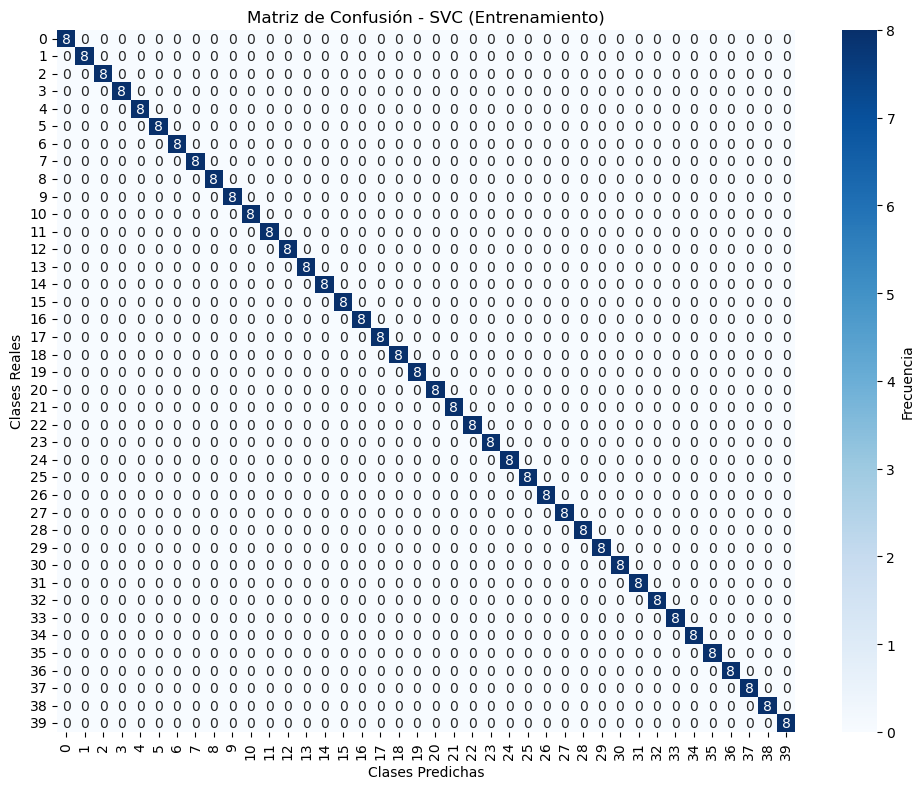


+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++
Accuracy (Prueba): 0.875
Classification report (Prueba):
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       1.00      1.00      1.00         2
           2       0.50      1.00      0.67         2
           3       0.00      0.00      0.00         2
           4       1.00      1.00      1.00         2
           5       1.00      0.50      0.67         2
           6       1.00      0.50      0.67         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       0.33      1.00      0.50         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      1.

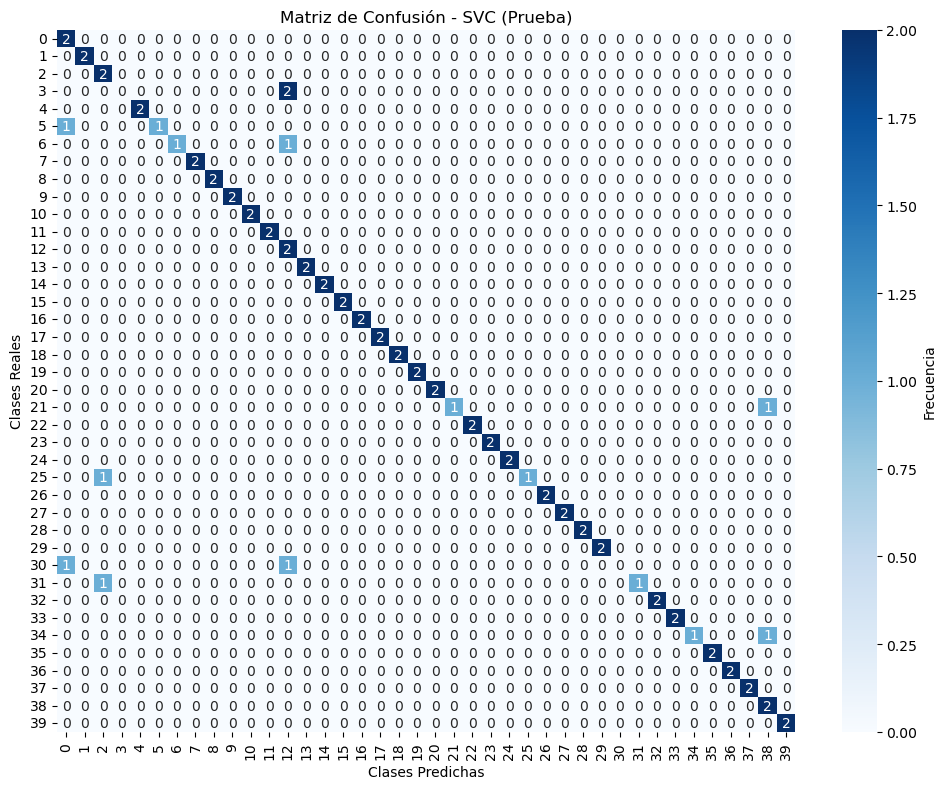

In [20]:
# Parámetros de búsqueda para el GridSearchCV
param_grid = {
    'C': np.logspace(0, 2, 5), # 1., 3.16227766, 10., 31.6227766, 100
    'gamma': np.logspace(-4, 0, 5) # 0.0001, 0.001 , 0.01  , 0.1   , 1.
}

# Iniciar la medición del tiempo
start_time = time.time()

# Crear el objeto GridSearchCV y ajustar a los datos
grid = GridSearchCV(SVC(random_state=42, kernel='rbf'), param_grid, refit=True, verbose=2, cv=5, n_jobs=-1)
grid.fit(X_pca_train_scaled, y_pca_train)

# Medir el tiempo después de GridSearchCV
end_time = time.time()
elapsed_time_ms = (end_time - start_time) * 1000  # en milisegundos
print(f"\nTiempo de ejecución del GridSearchCV: {elapsed_time_ms:.2f} ms")

# Mejor estimador
print("\nMejores parámetros encontrados:", grid.best_params_)
best_model = grid.best_estimator_

# Evaluación de los resultados
print("\n+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++")
evaluar_modelo(best_model, X_pca_train_scaled, y_pca_train, dataset_type="Entrenamiento", model_type="SVC")
print("\n+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++")
evaluar_modelo(best_model, X_pca_test_scaled, y_pca_test, dataset_type="Prueba", model_type="SVC")

#### Tercera búsqueda

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Tiempo de ejecución del GridSearchCV: 124.52 ms

Mejores parámetros encontrados: {'C': 3.5, 'gamma': 0.000875}

+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++
Accuracy (Entrenamiento): 1.0
Classification report (Entrenamiento):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00         8
           6       1.00      1.00      1.00         8
           7       1.00      1.00      1.00         8
           8       1.00      1.00      1.00         8
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         8
          11       1.00      1.00      1.00         8


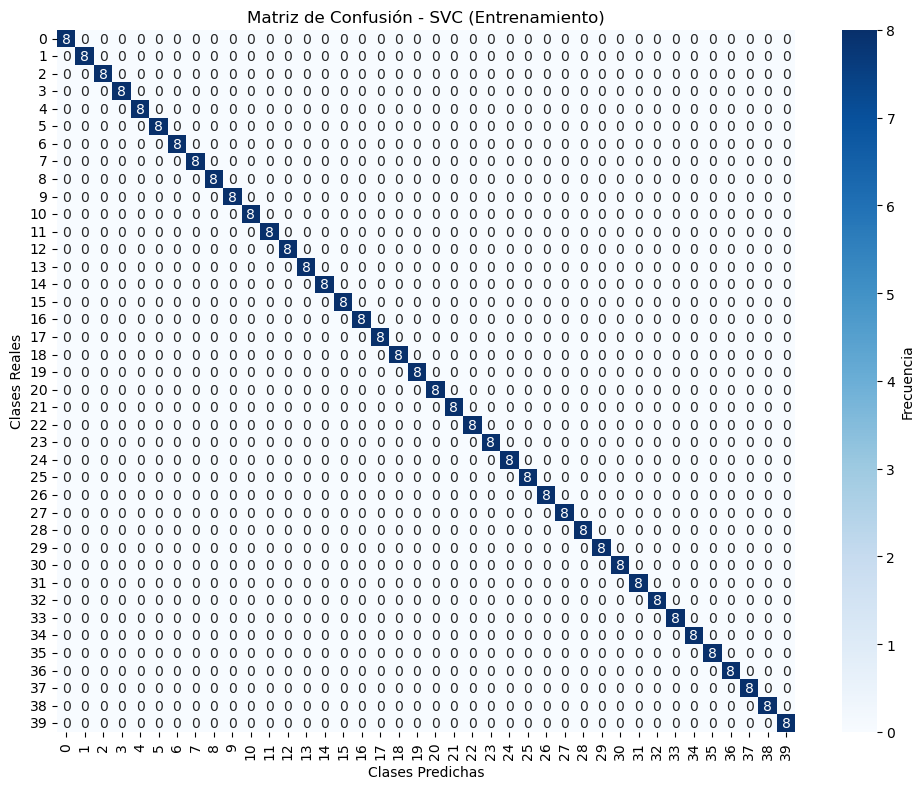


+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++
Accuracy (Prueba): 0.875
Classification report (Prueba):
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       1.00      1.00      1.00         2
           2       0.50      1.00      0.67         2
           3       0.00      0.00      0.00         2
           4       1.00      1.00      1.00         2
           5       1.00      0.50      0.67         2
           6       1.00      0.50      0.67         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       0.33      1.00      0.50         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      1.

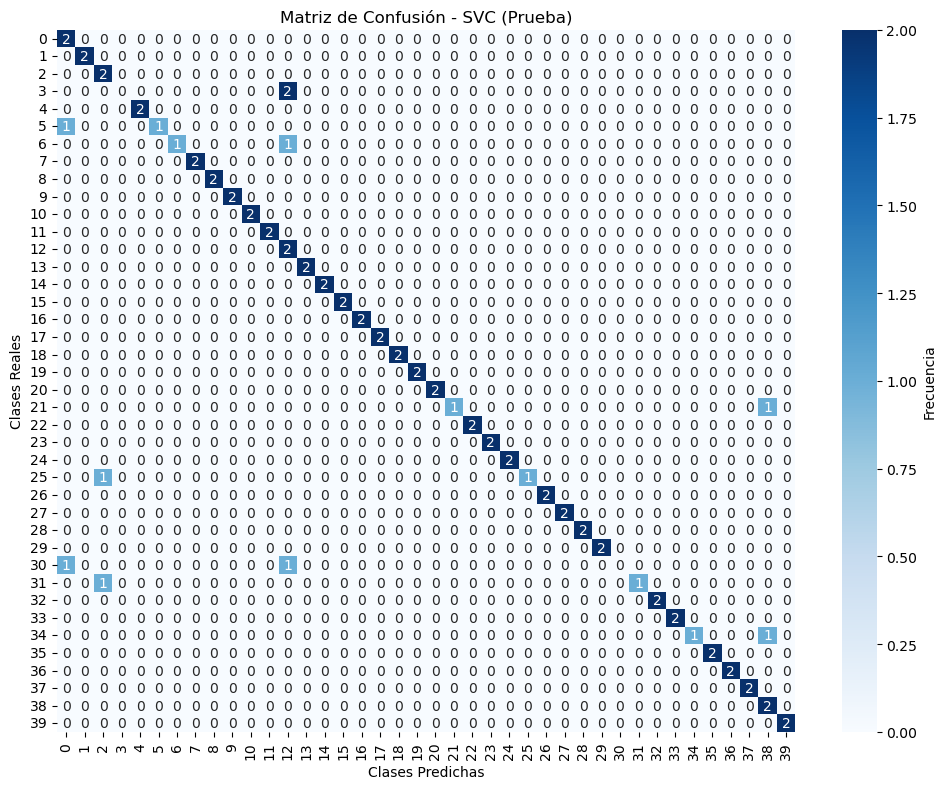

In [21]:
# Parámetros de búsqueda para el GridSearchCV
param_grid = {
    'C': np.linspace(2, 4, 5), # 2. , 2.5, 3. , 3.5, 4.
    'gamma': np.linspace(0.0005, 0.002, 5) # 0.0005  , 0.000875, 0.00125 , 0.001625, 0.002
}

# Iniciar la medición del tiempo
start_time = time.time()

# Crear el objeto GridSearchCV y ajustar a los datos
grid = GridSearchCV(SVC(random_state=42, kernel='rbf'), param_grid, refit=True, verbose=2, cv=5, n_jobs=-1)
grid.fit(X_pca_train_scaled, y_pca_train)

# Medir el tiempo después de GridSearchCV
end_time = time.time()
elapsed_time_ms = (end_time - start_time) * 1000  # en milisegundos
print(f"\nTiempo de ejecución del GridSearchCV: {elapsed_time_ms:.2f} ms")

# Mejor estimador
print("\nMejores parámetros encontrados:", grid.best_params_)
best_model = grid.best_estimator_

# Evaluación de los resultados
print("\n+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++")
evaluar_modelo(best_model, X_pca_train_scaled, y_pca_train, dataset_type="Entrenamiento", model_type="SVC")
print("\n+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++")
evaluar_modelo(best_model, X_pca_test_scaled, y_pca_test, dataset_type="Prueba", model_type="SVC")

### Conclusiones

## 6. LinearSVC y SVC sobre datos transformados con LDA

> _Realizar 4. usando los datos comprimidos mediante LDA._

### LinearSVC

#### Primera búsqueda

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Tiempo de ejecución del GridSearchCV: 406.86 ms

Mejores parámetros encontrados: {'C': 0.001}

+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++
Accuracy (Entrenamiento): 1.0
Classification report (Entrenamiento):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00         8
           6       1.00      1.00      1.00         8
           7       1.00      1.00      1.00         8
           8       1.00      1.00      1.00         8
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         8
          11       1.00      1.00      1.00         8
          12       

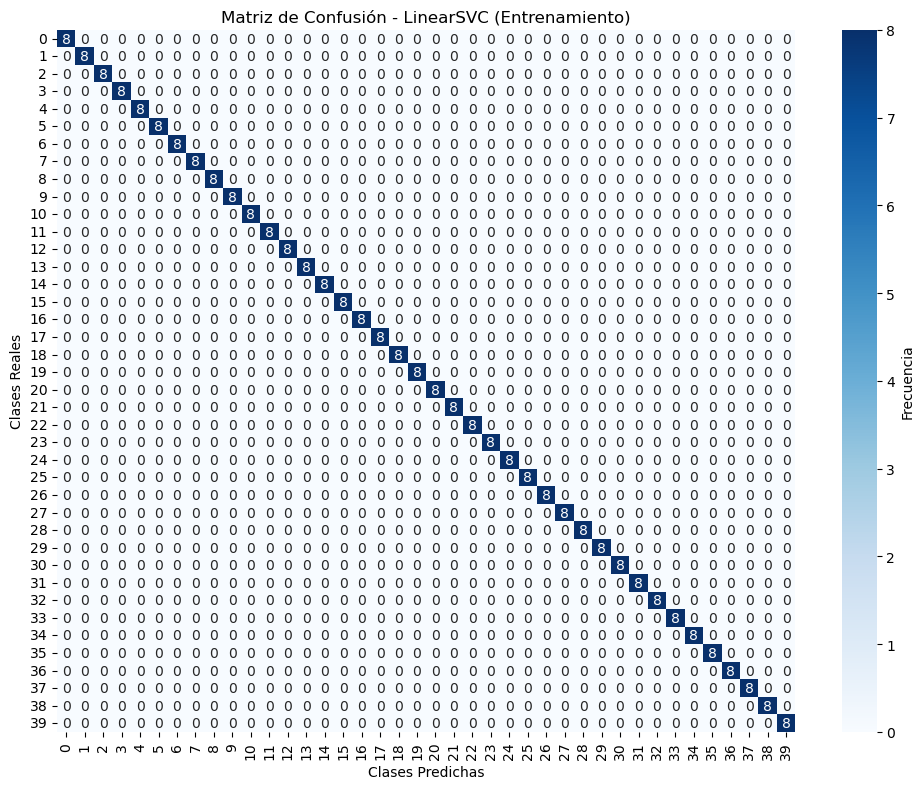


+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++
Accuracy (Prueba): 1.0
Classification report (Prueba):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      1.00

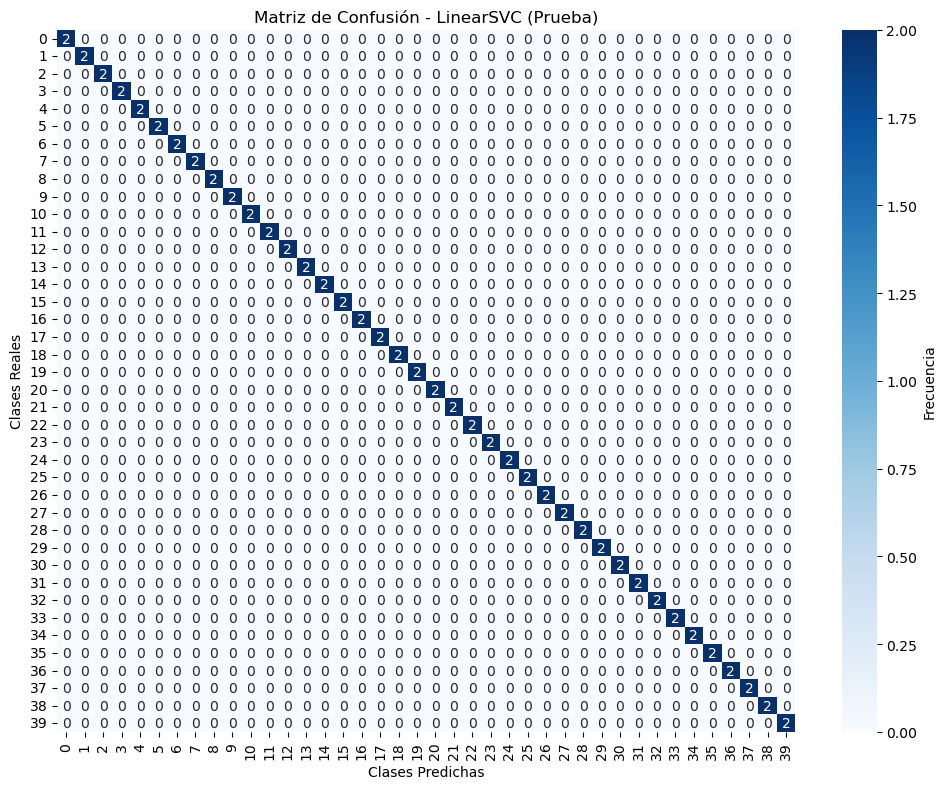

In [22]:
# Parámetros de búsqueda para LinearSVC
param_grid = {
    'C': np.logspace(-3, 2, 6),  # 0.001,   0.01 ,   0.1  ,   1.   ,  10.   , 100.
}

# Iniciar la medición del tiempo
start_time = time.time()

# Crear el objeto GridSearchCV y ajustar a los datos
grid = GridSearchCV(LinearSVC(random_state=42), param_grid, refit=True, verbose=2, cv=5, n_jobs=-1)
grid.fit(X_lda_train_scaled, y_lda_train)

# Medir el tiempo después de GridSearchCV
end_time = time.time()
elapsed_time_ms = (end_time - start_time) * 1000  # en milisegundos
print(f"\nTiempo de ejecución del GridSearchCV: {elapsed_time_ms:.2f} ms")

# Mejor estimador
print("\nMejores parámetros encontrados:", grid.best_params_)
best_model = grid.best_estimator_

# Evaluación de los resultados
print("\n+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++")
evaluar_modelo(best_model, X_lda_train_scaled, y_lda_train, dataset_type="Entrenamiento", model_type="LinearSVC")
print("\n+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++")
evaluar_modelo(best_model, X_lda_test_scaled, y_lda_test, dataset_type="Prueba", model_type="LinearSVC")

#### Segunda búsqueda

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Tiempo de ejecución del GridSearchCV: 26.20 ms

Mejores parámetros encontrados: {'C': 1e-05}

+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++
Accuracy (Entrenamiento): 1.0
Classification report (Entrenamiento):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00         8
           6       1.00      1.00      1.00         8
           7       1.00      1.00      1.00         8
           8       1.00      1.00      1.00         8
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         8
          11       1.00      1.00      1.00         8
          12       1

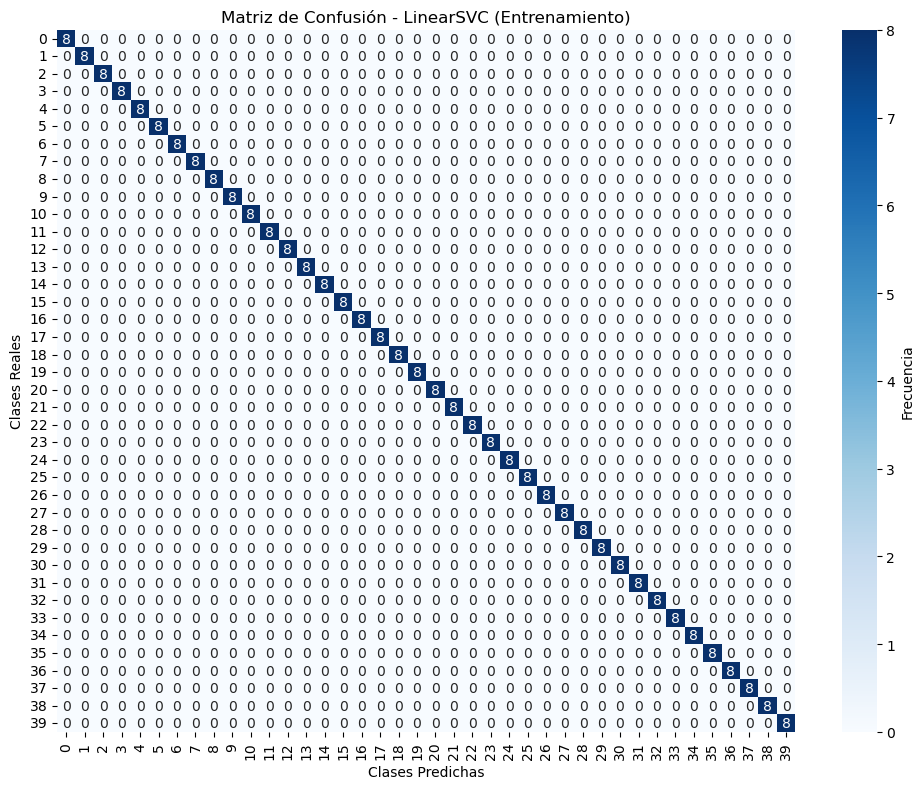


+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++
Accuracy (Prueba): 1.0
Classification report (Prueba):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      1.00

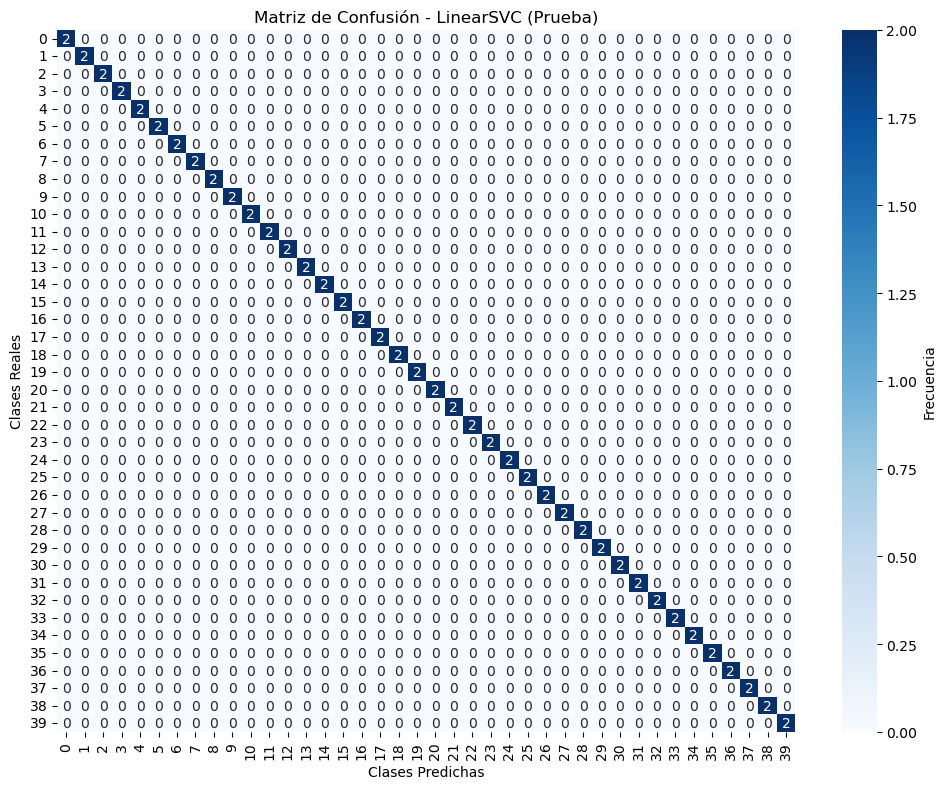

In [23]:
# Parámetros de búsqueda para LinearSVC
param_grid = {
    'C': np.logspace(-5, -2, 4), # 0.00001, 0.0001 , 0.001  , 0.01
}

# Iniciar la medición del tiempo
start_time = time.time()

# Crear el objeto GridSearchCV y ajustar a los datos
grid = GridSearchCV(LinearSVC(random_state=42), param_grid, refit=True, verbose=2, cv=5, n_jobs=-1)
grid.fit(X_lda_train_scaled, y_lda_train)

# Medir el tiempo después de GridSearchCV
end_time = time.time()
elapsed_time_ms = (end_time - start_time) * 1000  # en milisegundos
print(f"\nTiempo de ejecución del GridSearchCV: {elapsed_time_ms:.2f} ms")

# Mejor estimador
print("\nMejores parámetros encontrados:", grid.best_params_)
best_model = grid.best_estimator_

# Evaluación de los resultados
print("\n+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++")
evaluar_modelo(best_model, X_lda_train_scaled, y_lda_train, dataset_type="Entrenamiento", model_type="LinearSVC")
print("\n+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++")
evaluar_modelo(best_model, X_lda_test_scaled, y_lda_test, dataset_type="Prueba", model_type="LinearSVC")

### SVC

#### Primera búsqueda

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Tiempo de ejecución del GridSearchCV: 110.43 ms

Mejores parámetros encontrados: {'C': 1.0, 'gamma': 0.01}

+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++
Accuracy (Entrenamiento): 1.0
Classification report (Entrenamiento):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00         8
           6       1.00      1.00      1.00         8
           7       1.00      1.00      1.00         8
           8       1.00      1.00      1.00         8
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         8
          11       1.00      1.00      1.00         8
    

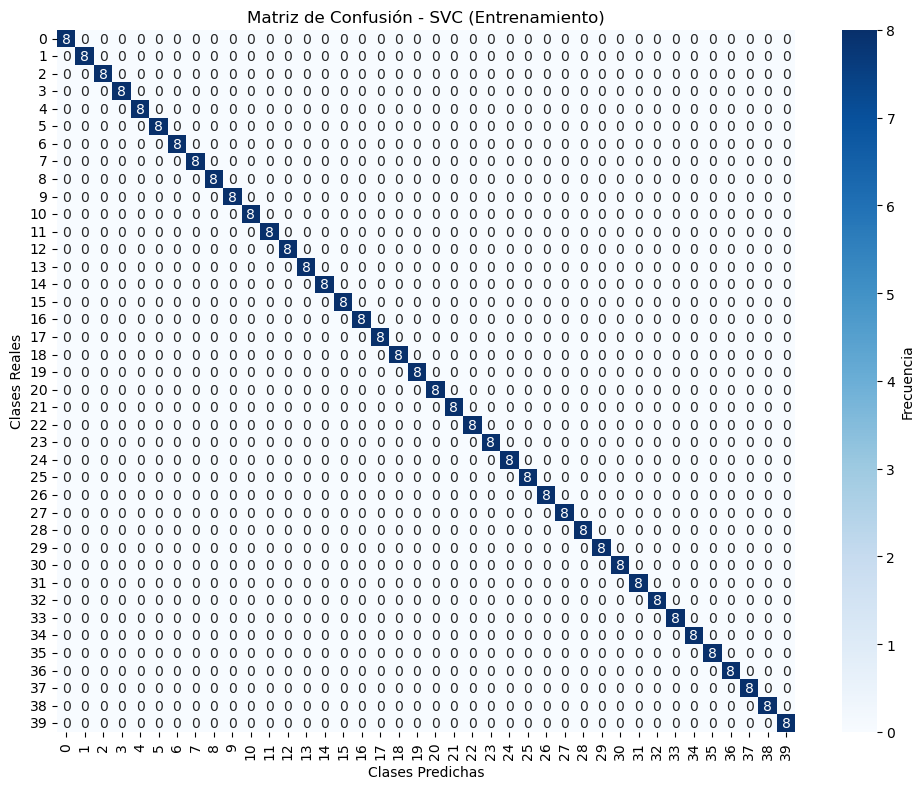


+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++
Accuracy (Prueba): 1.0
Classification report (Prueba):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      1.00

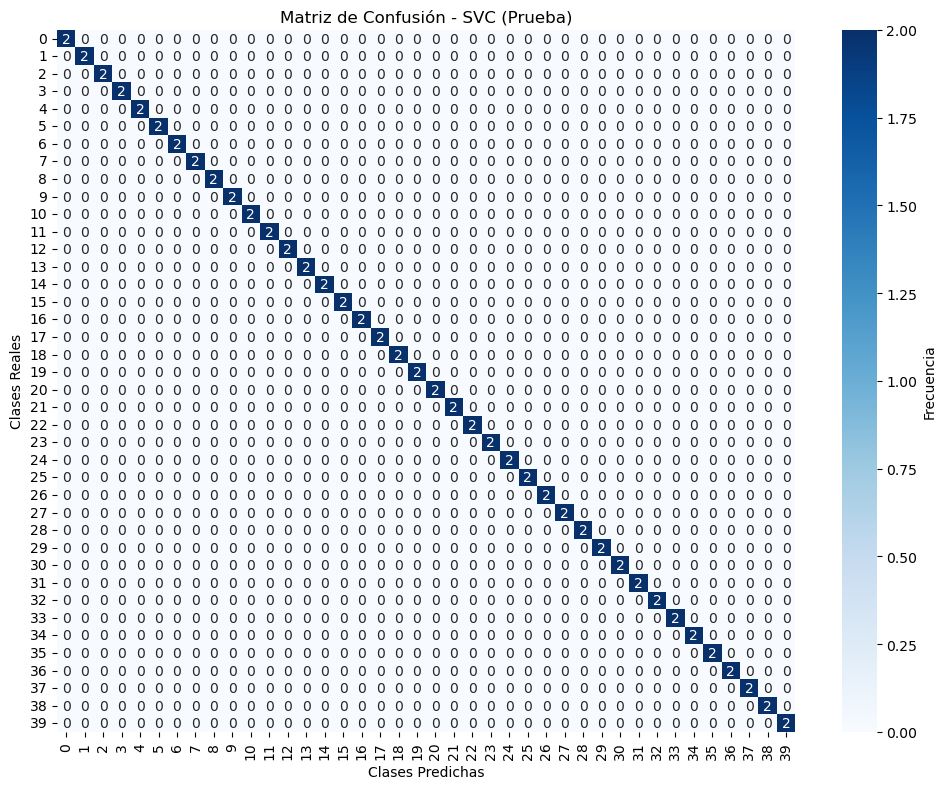

In [24]:
# Parámetros de búsqueda para el GridSearchCV
param_grid = {
    'C': np.logspace(-2, 2, 5),  # 0.01,   0.1 ,   1.  ,  10.  , 100.
    'gamma': np.logspace(-2, 2, 5)
}

# Iniciar la medición del tiempo
start_time = time.time()

# Crear el objeto GridSearchCV y ajustar a los datos
grid = GridSearchCV(SVC(random_state=42, kernel='rbf'), param_grid, refit=True, verbose=2, cv=5, n_jobs=-1)
grid.fit(X_lda_train_scaled, y_lda_train)

# Medir el tiempo después de GridSearchCV
end_time = time.time()
elapsed_time_ms = (end_time - start_time) * 1000  # en milisegundos
print(f"\nTiempo de ejecución del GridSearchCV: {elapsed_time_ms:.2f} ms")

# Mejor estimador
print("\nMejores parámetros encontrados:", grid.best_params_)
best_model = grid.best_estimator_

# Evaluación de los resultados
print("\n+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++")
evaluar_modelo(best_model, X_lda_train_scaled, y_lda_train, dataset_type="Entrenamiento", model_type="SVC")
print("\n+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++")
evaluar_modelo(best_model, X_lda_test_scaled, y_lda_test, dataset_type="Prueba", model_type="SVC")

#### Segunda búsqueda

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Tiempo de ejecución del GridSearchCV: 1595.49 ms

Mejores parámetros encontrados: {'C': 0.447213595499958, 'gamma': 0.01}

+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++
Accuracy (Entrenamiento): 1.0
Classification report (Entrenamiento):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00         8
           6       1.00      1.00      1.00         8
           7       1.00      1.00      1.00         8
           8       1.00      1.00      1.00         8
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         8
          11       1.00      1.00      1.00

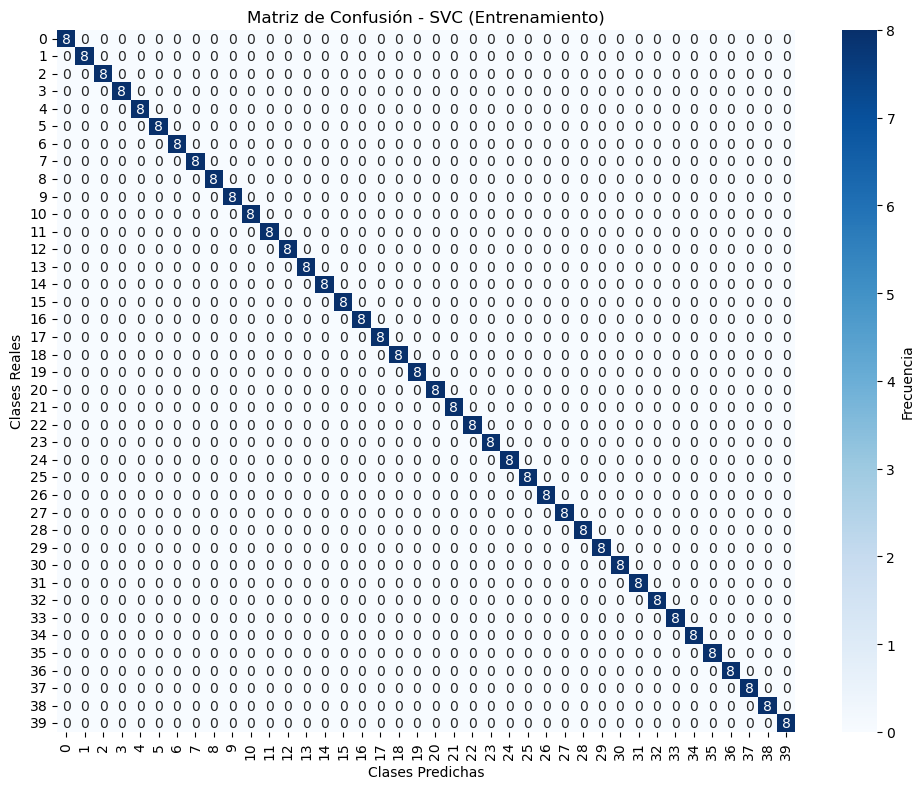


+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++
Accuracy (Prueba): 1.0
Classification report (Prueba):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      1.00

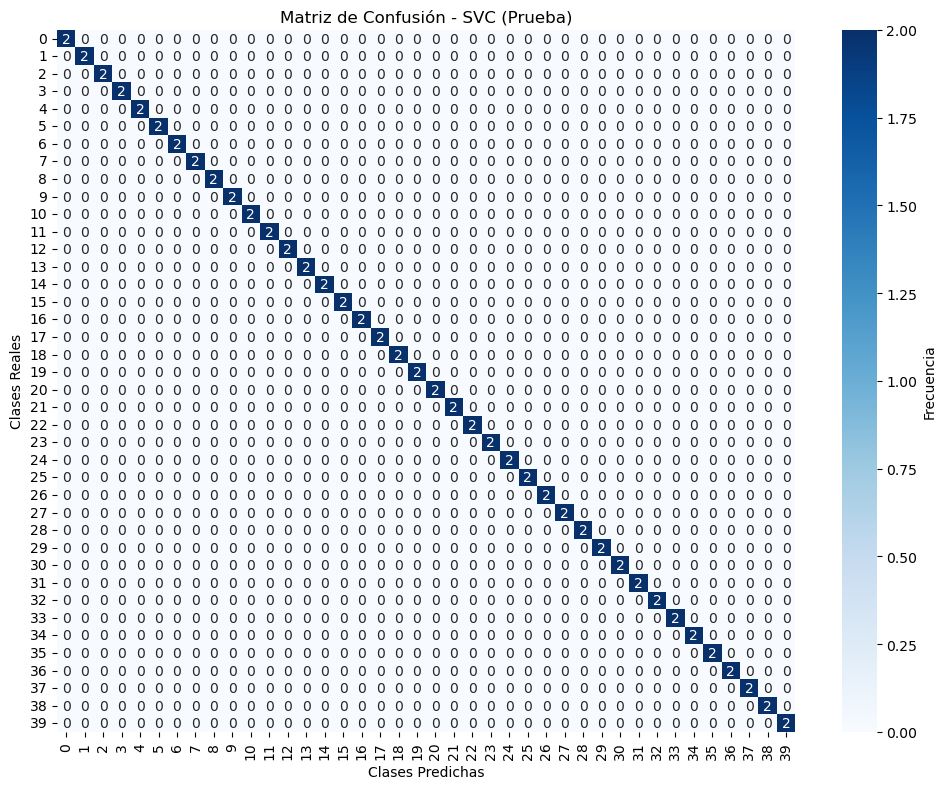

In [25]:
# Parámetros de búsqueda para el GridSearchCV
param_grid = {
    'C': np.logspace(np.log10(0.2), np.log10(5), 5),  # 0.2  , 0.4472, 1. , 2.2361, 5.
    'gamma': np.logspace(-5, -1, 5) # 0.00001, 0.0001 , 0.001  , 0.01   , 0.1 
}

# Iniciar la medición del tiempo
start_time = time.time()

# Crear el objeto GridSearchCV y ajustar a los datos
grid = GridSearchCV(SVC(random_state=42, kernel='rbf'), param_grid, refit=True, verbose=2, cv=5, n_jobs=-1)
grid.fit(X_lda_train_scaled, y_lda_train)

# Medir el tiempo después de GridSearchCV
end_time = time.time()
elapsed_time_ms = (end_time - start_time) * 1000  # en milisegundos
print(f"\nTiempo de ejecución del GridSearchCV: {elapsed_time_ms:.2f} ms")

# Mejor estimador
print("\nMejores parámetros encontrados:", grid.best_params_)
best_model = grid.best_estimator_

# Evaluación de los resultados
print("\n+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++")
evaluar_modelo(best_model, X_lda_train_scaled, y_lda_train, dataset_type="Entrenamiento", model_type="SVC")
print("\n+++ RESULTADOS PARA EL CONJUNTO DE PRUEBA +++")
evaluar_modelo(best_model, X_lda_test_scaled, y_lda_test, dataset_type="Prueba", model_type="SVC")

### Conclusiones

Clasifica todo perfecto

## 7.Comparar los parámetros resultantes para los mejores estimadores

> _Comparar los parámetros resultantes para los mejores estimadores obtenidos en 4., 5. y 6. así como sus accuracies y los tiempos de ejecución totales de las búsquedas y la media de las búsquedas de cada GridSearchCV teniendo en cuenta el número de valores de los parámetros en cada GridSearchCV._

## Conclusiones